# ADNI Data Extraction

### Plan
* Static data extraction and filtering,
* Longitudinal data extraction with patient filtering,
* Data validation and consistency checks,
* Final dataset creation

### Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

### Utility Functions

In [2]:
def extract_patient_id(df, key):
    """Extract and process patient ID"""
    df = df.sort_values(by=[key])
    return df

def extract_patient_id_two_keys(df, key1, key2):
    """Extract and sort by two keys"""
    df = df.sort_values(by=[key1, key2])
    return df

def validate_patient_consistency(static_patients, long_patients, stage_name):
    """Validate patient consistency between datasets"""
    print(f"\n=== {stage_name} ===")
    print(f"Static patients: {len(static_patients)}")
    print(f"Longitudinal patients: {len(long_patients)}")
    
    # Check for patients in longitudinal but not in static
    extra_in_long = set(long_patients) - set(static_patients)
    if extra_in_long:
        print(f"⚠️  {len(extra_in_long)} patients in longitudinal data but not in static data")
        
    # Check for patients in static but not in longitudinal
    missing_in_long = set(static_patients) - set(long_patients)
    if missing_in_long:
        print(f"⚠️  {len(missing_in_long)} patients in static data but not in longitudinal data")
        
    # Common patients
    common_patients = set(static_patients) & set(long_patients)
    print(f"✅ Common patients: {len(common_patients)}")
    
    return list(common_patients)

### Configuration

In [3]:
# Configuration
print("Target dataset: ADNI")

base_path = "/path/to/HyperNSDE/datasets/ADNI/original_data_files/"
# Data paths
file_merge = base_path + "ADNIMERGE_10Jun2025.csv"
print(f"ADNI data file: {file_merge}")

Target dataset: ADNI
ADNI data file: /path/to/HyperNSDE/datasets/ADNI/original_data_files/ADNIMERGE_10Jun2025.csv


### Load and Process ADNI Data

In [4]:
# Load ADNI data
df_merge = pd.read_csv(file_merge, sep=",")
print("=== ADNI Data Processing ===")
print(f"Raw ADNI data shape: {df_merge.shape}")

# Format data
df_merge = extract_patient_id_two_keys(df_merge, 'PTID', 'EXAMDATE')
df_merge = df_merge.drop(columns=['RID', 'COLPROT', 'ORIGPROT', 'SITE', 'VISCODE'])

print(f"Processed ADNI data shape: {df_merge.shape}")
df_merge.head()

=== ADNI Data Processing ===
Raw ADNI data shape: (16421, 116)
Processed ADNI data shape: (16421, 111)


,PTID,EXAMDATE,DX_bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,...,PTAU_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl,Years_bl,Month_bl,Month,M,update_stamp
669,002_S_0295,2006-05-09,CN,84.8,Male,18,Not Hisp/Latino,White,Married,1.0,...,34.73,NaN,NaN,NaN,NaN,0.00000,0.00000,0,0,2023-07-07 04:59:43.0
670,002_S_0295,2006-11-02,CN,84.8,Male,18,Not Hisp/Latino,White,Married,1.0,...,34.73,NaN,NaN,NaN,NaN,0.48460,5.80328,6,6,2023-07-07 04:59:43.0
671,002_S_0295,2007-05-25,CN,84.8,Male,18,Not Hisp/Latino,White,Married,1.0,...,34.73,NaN,NaN,NaN,NaN,1.04312,12.49180,12,12,2023-07-07 04:59:43.0
5828,002_S_0295,2007-11-12,CN,84.8,Male,18,Not Hisp/Latino,White,Married,1.0,...,34.73,NaN,NaN,NaN,NaN,1.51129,18.09840,18,18,2023-07-07 04:59:43.0
672,002_S_0295,2008-08-04,CN,84.8,Male,18,Not Hisp/Latino,White,Married,1.0,...,34.73,NaN,NaN,NaN,NaN,2.23956,26.81970,24,24,2023-07-07 04:59:43.0


### Identify Longitudinal vs Static Variables

In [5]:
# Get all variables (excluding patient ID and date)
variables = [col for col in df_merge.columns if col not in ['PTID', 'EXAMDATE']]

# Initialize lists
variables_longitudinales = ['PTID', 'EXAMDATE']
variables_statiques = ['PTID', 'EXAMDATE']

# Determine if each variable is time-dependent
print("=== Variable Classification ===")
for var in variables:
    variations = df_merge.groupby('PTID')[var].nunique()
    if any(variations > 1):
        variables_longitudinales.append(var)
    else: 
        variables_statiques.append(var)

print(f"Longitudinal variables: {len(variables_longitudinales)}")
print(f"Static variables: {len(variables_statiques)}")

# Show some examples
print(f"\nSample longitudinal variables: {variables_longitudinales[2:7]}")
print(f"Sample static variables: {variables_statiques[2:7]}")

=== Variable Classification ===
Longitudinal variables: 58
Static variables: 55

Sample longitudinal variables: ['FDG', 'PIB', 'AV45', 'FBB', 'ABETA']
Sample static variables: ['DX_bl', 'AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT']


In [6]:
print(variables_longitudinales)

['PTID', 'EXAMDATE', 'FDG', 'PIB', 'AV45', 'FBB', 'ABETA', 'TAU', 'PTAU', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR', 'FAQ', 'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang', 'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt', 'EcogSPTotal', 'FLDSTRENG', 'FSVERSION', 'IMAGEUID', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'DX', 'mPACCdigit', 'mPACCtrailsB', 'ABETA_bl', 'TAU_bl', 'PTAU_bl', 'Years_bl', 'Month_bl', 'Month', 'M', 'update_stamp']


### Process Static Data

In [7]:
# Create static data DataFrame
df_static = df_merge[variables_statiques].copy()

# Convert date column
df_static['EXAMDATE'] = pd.to_datetime(df_static['EXAMDATE'])

# Define categorical variables
categorical_vars = [
    'DX_bl', 'PTGENDER', 'PTETHCAT', 'PTRACCAT', 'PTMARRY', 
    'FLDSTRENG_bl', 'FSVERSION_bl'
]

# Process categorical variables
for col in categorical_vars:
    if col in df_static.columns:
        df_static[col] = df_static[col].replace([
            'Unknown', 'No Value Entered', 'Pt Refused To Answer'
        ], np.nan)
        df_static[col] = df_static[col].astype('category').cat.codes
        df_static[col] = df_static[col].replace(-1, np.nan)

print(f"Categorical variables processed: {len([col for col in categorical_vars if col in df_static.columns])}")

# Keep only first record per patient (skipna=True to handle missing values)
df_static = df_static.groupby('PTID').first(skipna=True)

print(f"Static data shape after processing: {df_static.shape}")
df_static.head()

Categorical variables processed: 7
Static data shape after processing: (2430, 54)


,EXAMDATE,DX_bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,EXAMDATE_bl,...,EcogSPLang_bl,EcogSPVisspat_bl,EcogSPPlan_bl,EcogSPOrgan_bl,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl
PTID,,,,,,,,,,,,,,,,,,,,,
002_S_0295,2006-05-09,1.0,84.8,1,18,1.0,5.0,1.0,1.0,2006-05-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
002_S_0413,2006-05-08,1.0,76.3,0,16,1.0,5.0,1.0,0.0,2006-05-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
002_S_0559,2006-06-20,1.0,79.3,1,16,1.0,5.0,3.0,1.0,2006-06-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
002_S_0619,2006-06-20,0.0,77.5,1,12,1.0,5.0,1.0,2.0,2006-06-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
002_S_0685,2006-07-20,1.0,89.6,0,16,1.0,5.0,1.0,0.0,2006-07-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_static = df_static.drop(columns=['EXAMDATE'])

### Define Static Data Types

In [9]:
# Define static data types
static_types = {var: ("real", 1, 1) for var in df_static.columns}

# Set categorical variables
for var in categorical_vars:
    if var in df_static.columns:
        unique_vals = df_static[var].dropna().unique()
        static_types[var] = ("cat", len(unique_vals), 1)

# Define real variables
real_vars = [
    'AGE', 'PTEDUCAT', 'APOE4', 'CDRSB', 'ADAS11', 'ADAS13', 
    'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 
    'RAVLT_forgetting', 'RAVLT_perc_forgetting', 'LDELTOTAL', 
    'DIGITSCOR', 'TRABSCOR', 'FAQ', 'mPACCdigit', 'mPACCtrailsB'
]

for var in real_vars:
    if var in df_static.columns:
        static_types[var] = ("real", 1, 1)

print("Static data types defined")
print(f"Number of static variables: {len(static_types)}")
print(static_types)

Static data types defined
Number of static variables: 53
{'DX_bl': ('cat', 5, 1), 'AGE': ('real', 1, 1), 'PTGENDER': ('cat', 2, 1), 'PTEDUCAT': ('real', 1, 1), 'PTETHCAT': ('cat', 2, 1), 'PTRACCAT': ('cat', 6, 1), 'PTMARRY': ('cat', 4, 1), 'APOE4': ('real', 1, 1), 'EXAMDATE_bl': ('real', 1, 1), 'CDRSB_bl': ('real', 1, 1), 'ADAS11_bl': ('real', 1, 1), 'ADAS13_bl': ('real', 1, 1), 'ADASQ4_bl': ('real', 1, 1), 'MMSE_bl': ('real', 1, 1), 'RAVLT_immediate_bl': ('real', 1, 1), 'RAVLT_learning_bl': ('real', 1, 1), 'RAVLT_forgetting_bl': ('real', 1, 1), 'RAVLT_perc_forgetting_bl': ('real', 1, 1), 'LDELTOTAL_BL': ('real', 1, 1), 'DIGITSCOR_bl': ('real', 1, 1), 'TRABSCOR_bl': ('real', 1, 1), 'FAQ_bl': ('real', 1, 1), 'mPACCdigit_bl': ('real', 1, 1), 'mPACCtrailsB_bl': ('real', 1, 1), 'FLDSTRENG_bl': ('cat', 2, 1), 'FSVERSION_bl': ('cat', 3, 1), 'IMAGEUID_bl': ('real', 1, 1), 'Ventricles_bl': ('real', 1, 1), 'Hippocampus_bl': ('real', 1, 1), 'WholeBrain_bl': ('real', 1, 1), 'Entorhinal_bl': ('rea

### Process Longitudinal Data

In [10]:
# Create longitudinal data DataFrame
df_long = df_merge[variables_longitudinales].copy()

# Remove problematic columns with string values in numeric columns or not interesting
problematic_cols = ['ABETA', 'TAU', 'PTAU', 'ABETA_bl', 'TAU_bl', 'PTAU_bl', 'FLDSTRENG', 'FSVERSION', 'DX', 'Years_bl', 'Month_bl', 'Month', 'M', 'update_stamp', 'IMAGEUID', 'RAVLT_learning', 'RAVLT_forgetting']
df_long = df_long.drop(columns=[col for col in problematic_cols if col in df_long.columns])

# Convert date column
df_long['EXAMDATE'] = pd.to_datetime(df_long['EXAMDATE'])

print(f"Longitudinal data shape: {df_long.shape}")
print(f"Longitudinal variables: {list(df_long.columns[2:])}")
df_long.head()

Longitudinal data shape: (16421, 41)
Longitudinal variables: ['FDG', 'PIB', 'AV45', 'FBB', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR', 'FAQ', 'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang', 'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt', 'EcogSPTotal', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'mPACCdigit', 'mPACCtrailsB']


,PTID,EXAMDATE,FDG,PIB,AV45,FBB,CDRSB,ADAS11,ADAS13,ADASQ4,...,EcogSPTotal,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV,mPACCdigit,mPACCtrailsB
669,002_S_0295,2006-05-09,NaN,NaN,NaN,NaN,0.0,3.00,4.00,1.0,...,NaN,39130.0,7068.0,1076350.0,3619.0,16561.0,19829.0,1633860.0,-0.110553,-3.635890
670,002_S_0295,2006-11-02,NaN,NaN,NaN,NaN,0.0,5.33,6.33,1.0,...,NaN,39101.0,6896.0,1089680.0,3662.0,18041.0,19825.0,1645300.0,-0.294118,0.367504
671,002_S_0295,2007-05-25,NaN,NaN,NaN,NaN,0.0,4.67,5.67,1.0,...,NaN,40554.0,6894.0,1085210.0,3572.0,17386.0,19917.0,1651500.0,3.122910,2.405730
5828,002_S_0295,2007-11-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
672,002_S_0295,2008-08-04,NaN,NaN,NaN,NaN,0.0,3.67,5.67,2.0,...,NaN,42423.0,6839.0,1067480.0,3855.0,18159.0,19269.0,1650520.0,0.095772,-1.734870


In [11]:
# On calcule le nombre moyen de valeurs différentes par patient pour chaque colonne
nunique_per_patient = df_long.groupby('PTID').nunique().mean()

# On identifie les colonnes constantes (moyenne proche de 1)
constante_features = nunique_per_patient[nunique_per_patient <= 1.0].index.tolist()
varying_features = nunique_per_patient[nunique_per_patient > 1.0].index.tolist()

print(f"Colonnes constantes par patient : {constante_features}")
print(f"Colonnes qui varient dans le temps : {varying_features}")

Colonnes constantes par patient : ['PIB', 'FBB']
Colonnes qui varient dans le temps : ['EXAMDATE', 'FDG', 'AV45', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR', 'FAQ', 'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang', 'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt', 'EcogSPTotal', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'mPACCdigit', 'mPACCtrailsB']


In [12]:
df_long = df_long.drop(columns=constante_features)

In [13]:
# On calcule l'écart-type standard moyen au sein des groupes patients
# Un std de 0 signifie que la valeur ne bouge jamais pour le patient
varying_features.pop(0)
intra_patient_std = df_long.groupby('PTID')[varying_features].std().mean()

# Trier par variabilité (du plus stable au plus changeant)
print("Variabilité moyenne par variable (Ecart-type intra-patient) :")
print(intra_patient_std.sort_values())

Variabilité moyenne par variable (Ecart-type intra-patient) :
AV45                         0.050762
FDG                          0.053460
EcogPtTotal                  0.229969
EcogPtVisspat                0.240951
EcogPtPlan                   0.251891
EcogSPTotal                  0.268396
EcogSPVisspat                0.283957
EcogPtOrgan                  0.288518
EcogPtLang                   0.293264
EcogSPLang                   0.303063
EcogSPOrgan                  0.312133
EcogSPPlan                   0.315465
EcogSPMem                    0.333162
EcogPtMem                    0.346468
EcogPtDivatt                 0.359222
EcogSPDivatt                 0.377919
CDRSB                        1.010417
ADASQ4                       1.113593
MMSE                         1.741176
MOCA                         1.926487
LDELTOTAL                    2.039772
FAQ                          2.546783
mPACCtrailsB                 2.703101
mPACCdigit                   2.922016
ADAS11                    

### Validate Patient Consistency

In [14]:
# Validate patient consistency
static_patients = df_static.index.tolist()
longitudinal_patients = df_long['PTID'].unique().tolist()

common_patients = validate_patient_consistency(static_patients, longitudinal_patients, "Patient Consistency Check")

# Filter both datasets to only include common patients
df_static = df_static.loc[common_patients]
df_long = df_long[df_long['PTID'].isin(common_patients)].copy()

print(f"\nAfter filtering:")
print(f"Static data: {len(df_static)} patients")
print(f"Longitudinal data: {df_long['PTID'].nunique()} patients")

# Verify consistency
assert len(df_static) == df_long['PTID'].nunique(), "Patient counts must match!"
print("✅ Patient consistency verified!")


=== Patient Consistency Check ===
Static patients: 2430
Longitudinal patients: 2430
✅ Common patients: 2430

After filtering:
Static data: 2430 patients
Longitudinal data: 2430 patients
✅ Patient consistency verified!


### Time normalization

In [15]:
df_long_clean = df_long.copy()
dt = pd.to_datetime(df_long_clean["EXAMDATE"])
df_long_clean['EXAMDATE'] = (
    (dt - dt.min())
    .dt.total_seconds()
    / 86400.0
)
df_long_clean.head()

,PTID,EXAMDATE,FDG,AV45,CDRSB,ADAS11,ADAS13,ADASQ4,MMSE,RAVLT_immediate,...,EcogSPTotal,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV,mPACCdigit,mPACCtrailsB
669,002_S_0295,244.0,NaN,NaN,0.0,3.00,4.00,1.0,28.0,56.0,...,NaN,39130.0,7068.0,1076350.0,3619.0,16561.0,19829.0,1633860.0,-0.110553,-3.635890
670,002_S_0295,421.0,NaN,NaN,0.0,5.33,6.33,1.0,28.0,50.0,...,NaN,39101.0,6896.0,1089680.0,3662.0,18041.0,19825.0,1645300.0,-0.294118,0.367504
671,002_S_0295,625.0,NaN,NaN,0.0,4.67,5.67,1.0,30.0,53.0,...,NaN,40554.0,6894.0,1085210.0,3572.0,17386.0,19917.0,1651500.0,3.122910,2.405730
5828,002_S_0295,796.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
672,002_S_0295,1062.0,NaN,NaN,0.0,3.67,5.67,2.0,29.0,45.0,...,NaN,42423.0,6839.0,1067480.0,3855.0,18159.0,19269.0,1650520.0,0.095772,-1.734870


In [16]:
print("=== Normalizing to First Visit ===")
print(f"Before normalization - Time range: {df_long_clean['EXAMDATE'].min()} to {df_long_clean['EXAMDATE'].max()}")

# Apply normalization
df_long_clean = df_long_clean.sort_values(by=['PTID', 'EXAMDATE'])
df_long_clean['EXAMDATE'] = df_long_clean.groupby('PTID')['EXAMDATE'].transform(lambda x: x - x.min())

print(f"After normalization - Time range: {df_long_clean['EXAMDATE'].min()} to {df_long_clean['EXAMDATE'].max()}")
df_long_clean.head()

=== Normalizing to First Visit ===
Before normalization - Time range: 0.0 to 6573.0
After normalization - Time range: 0.0 to 6195.0


,PTID,EXAMDATE,FDG,AV45,CDRSB,ADAS11,ADAS13,ADASQ4,MMSE,RAVLT_immediate,...,EcogSPTotal,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV,mPACCdigit,mPACCtrailsB
669,002_S_0295,0.0,NaN,NaN,0.0,3.00,4.00,1.0,28.0,56.0,...,NaN,39130.0,7068.0,1076350.0,3619.0,16561.0,19829.0,1633860.0,-0.110553,-3.635890
670,002_S_0295,177.0,NaN,NaN,0.0,5.33,6.33,1.0,28.0,50.0,...,NaN,39101.0,6896.0,1089680.0,3662.0,18041.0,19825.0,1645300.0,-0.294118,0.367504
671,002_S_0295,381.0,NaN,NaN,0.0,4.67,5.67,1.0,30.0,53.0,...,NaN,40554.0,6894.0,1085210.0,3572.0,17386.0,19917.0,1651500.0,3.122910,2.405730
5828,002_S_0295,552.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
672,002_S_0295,818.0,NaN,NaN,0.0,3.67,5.67,2.0,29.0,45.0,...,NaN,42423.0,6839.0,1067480.0,3855.0,18159.0,19269.0,1650520.0,0.095772,-1.734870


### Exclusion of columns/features with too few observations

In [17]:
df_long_clean = df_long_clean.groupby(['PTID', 'EXAMDATE']).first().reset_index()
print(f"Number of patients: {df_long_clean['PTID'].nunique()}")
print(f"Longitudinal variables: {list(df_long_clean.columns[2:])}")
# df_long_clean.head()

Number of patients: 2430
Longitudinal variables: ['FDG', 'AV45', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR', 'FAQ', 'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang', 'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt', 'EcogSPTotal', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'mPACCdigit', 'mPACCtrailsB']


In [18]:
df_static.head()

,DX_bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,EXAMDATE_bl,CDRSB_bl,...,EcogSPLang_bl,EcogSPVisspat_bl,EcogSPPlan_bl,EcogSPOrgan_bl,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl
PTID,,,,,,,,,,,,,,,,,,,,,
128_S_1088,3.0,87.9,1,18,1.0,1.0,1.0,0.0,2007-01-05,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
027_S_1082,0.0,69.5,0,13,1.0,5.0,1.0,2.0,2006-12-06,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
035_S_2199,2.0,83.2,1,12,1.0,5.0,1.0,0.0,2010-12-06,0.5,...,3.00000,2.42857,2.0,3.33333,2.25,2.71795,1.103430,NaN,0.9526,NaN
114_S_6039,0.0,55.9,1,13,1.0,5.0,2.0,0.0,2017-08-09,2.0,...,2.44444,2.66667,2.2,2.83333,1.50,2.57895,0.945459,NaN,1.5883,NaN
037_S_4001,0.0,88.5,0,9,1.0,5.0,3.0,0.0,2011-03-02,5.5,...,1.00000,2.25000,3.6,3.66667,4.00,2.91667,1.039780,NaN,1.5033,NaN


In [19]:
# Remove PTID from static data
df_static_clean = df_static.copy().reset_index()
df_static_clean.head()

,PTID,DX_bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,EXAMDATE_bl,...,EcogSPLang_bl,EcogSPVisspat_bl,EcogSPPlan_bl,EcogSPOrgan_bl,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl
0,128_S_1088,3.0,87.9,1,18,1.0,1.0,1.0,0.0,2007-01-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,027_S_1082,0.0,69.5,0,13,1.0,5.0,1.0,2.0,2006-12-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,035_S_2199,2.0,83.2,1,12,1.0,5.0,1.0,0.0,2010-12-06,...,3.00000,2.42857,2.0,3.33333,2.25,2.71795,1.103430,NaN,0.9526,NaN
3,114_S_6039,0.0,55.9,1,13,1.0,5.0,2.0,0.0,2017-08-09,...,2.44444,2.66667,2.2,2.83333,1.50,2.57895,0.945459,NaN,1.5883,NaN
4,037_S_4001,0.0,88.5,0,9,1.0,5.0,3.0,0.0,2011-03-02,...,1.00000,2.25000,3.6,3.66667,4.00,2.91667,1.039780,NaN,1.5033,NaN


In [20]:
# Check for missing percentage of each variable in longitudinal data and static data and remove columns with less than 10% of data
print("=== Missing Data Analysis ===")

# Analyze missing data in longitudinal variables (excluding PTID and EXAMDATE)
long_vars_to_analyze = [col for col in df_long_clean.columns if col not in ['PTID', 'EXAMDATE']]
long_missing_pct = df_long_clean[long_vars_to_analyze].isna().sum() / len(df_long_clean) * 100
long_presence_pct = 100 - long_missing_pct

print(f"\nLongitudinal data missing percentages:")
print(f"Average missing: {long_missing_pct.mean():.1f}%")
print(f"Variables with >90% missing: {sum(long_missing_pct > 90)}")
print(f"Variables with >80% missing: {sum(long_missing_pct > 80)}")
print(f"Variables with >50% missing: {sum(long_missing_pct > 50)}")

# Analyze missing data in static variables
static_missing_pct = df_static_clean.isna().sum() / len(df_static_clean) * 100
static_presence_pct = 100 - static_missing_pct

print(f"\nStatic data missing percentages:")
print(f"Average missing: {static_missing_pct.mean():.1f}%")
print(f"Variables with >90% missing: {sum(static_missing_pct > 90)}")
print(f"Variables with >80% missing: {sum(static_missing_pct > 80)}")
print(f"Variables with >50% missing: {sum(static_missing_pct > 50)}")

print(df_long_clean.shape)
print(df_static_clean.shape)

=== Missing Data Analysis ===

Longitudinal data missing percentages:
Average missing: 46.6%
Variables with >90% missing: 0
Variables with >80% missing: 1
Variables with >50% missing: 18

Static data missing percentages:
Average missing: 18.7%
Variables with >90% missing: 1
Variables with >80% missing: 2
Variables with >50% missing: 4
(16418, 39)
(2430, 54)


In [21]:
# Remove columns with less than 10% of data (more than 90% missing)
long_vars_to_remove = long_missing_pct[long_missing_pct > 50].index.tolist()
static_vars_to_remove = static_missing_pct[static_missing_pct > 50].index.tolist()
static_vars_to_remove.append("EXAMDATE_bl")

print(f"\nRemoving longitudinal variables with >50% missing data:")
print(f"Variables to remove: {len(long_vars_to_remove)}")
if long_vars_to_remove:
    print(f"Removed variables: {long_vars_to_remove}")

print(f"\nRemoving static variables with >50% missing data:")
print(f"Variables to remove: {len(static_vars_to_remove)}")
if static_vars_to_remove:
    print(f"Removed variables: {static_vars_to_remove}")

# Remove the columns
df_long_clean = df_long_clean.drop(columns=long_vars_to_remove)
df_static_clean = df_static_clean.drop(columns=static_vars_to_remove)

print(f"\nAfter removing low-coverage variables:")
print(f"Longitudinal data shape: {df_long_clean.shape}")
print(f"Static data shape: {df_static_clean.shape}")

# Update the presence matrices
data_long_missing = (~df_long_clean.isna()).astype(int)
data_static_missing_filtered = (~df_static_clean.isna()).astype(int)

print(f"Updated presence matrices:")
print(f"Longitudinal presence matrix: {data_long_missing.shape}")
print(f"Static presence matrix: {data_static_missing_filtered.shape}")

for var in static_vars_to_remove:
    static_types.pop(var)


Removing longitudinal variables with >50% missing data:
Variables to remove: 18
Removed variables: ['FDG', 'AV45', 'DIGITSCOR', 'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang', 'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt', 'EcogSPTotal']

Removing static variables with >50% missing data:
Variables to remove: 5
Removed variables: ['DIGITSCOR_bl', 'PIB_bl', 'AV45_bl', 'FBB_bl', 'EXAMDATE_bl']

After removing low-coverage variables:
Longitudinal data shape: (16418, 21)
Static data shape: (2430, 49)
Updated presence matrices:
Longitudinal presence matrix: (16418, 21)
Static presence matrix: (2430, 49)


In [22]:
df_long_clean.head()

,PTID,EXAMDATE,CDRSB,ADAS11,ADAS13,ADASQ4,MMSE,RAVLT_immediate,RAVLT_perc_forgetting,LDELTOTAL,...,FAQ,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV,mPACCdigit,mPACCtrailsB
0,002_S_0295,0.0,0.0,3.00,4.00,1.0,28.0,56.0,23.0769,12.0,...,0.0,39130.0,7068.0,1076350.0,3619.0,16561.0,19829.0,1633860.0,-0.110553,-3.635890
1,002_S_0295,177.0,0.0,5.33,6.33,1.0,28.0,50.0,16.6667,NaN,...,0.0,39101.0,6896.0,1089680.0,3662.0,18041.0,19825.0,1645300.0,-0.294118,0.367504
2,002_S_0295,381.0,0.0,4.67,5.67,1.0,30.0,53.0,14.2857,15.0,...,0.0,40554.0,6894.0,1085210.0,3572.0,17386.0,19917.0,1651500.0,3.122910,2.405730
3,002_S_0295,552.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,002_S_0295,818.0,0.0,3.67,5.67,2.0,29.0,45.0,16.6667,10.0,...,0.0,42423.0,6839.0,1067480.0,3855.0,18159.0,19269.0,1650520.0,0.095772,-1.734870


In [23]:
df_static_clean.head()

,PTID,DX_bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,CDRSB_bl,...,EcogPtDivatt_bl,EcogPtTotal_bl,EcogSPMem_bl,EcogSPLang_bl,EcogSPVisspat_bl,EcogSPPlan_bl,EcogSPOrgan_bl,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl
0,128_S_1088,3.0,87.9,1,18,1.0,1.0,1.0,0.0,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,027_S_1082,0.0,69.5,0,13,1.0,5.0,1.0,2.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,035_S_2199,2.0,83.2,1,12,1.0,5.0,1.0,0.0,0.5,...,1.25,1.53846,2.875,3.00000,2.42857,2.0,3.33333,2.25,2.71795,1.103430
3,114_S_6039,0.0,55.9,1,13,1.0,5.0,2.0,0.0,2.0,...,3.75,2.86111,3.250,2.44444,2.66667,2.2,2.83333,1.50,2.57895,0.945459
4,037_S_4001,0.0,88.5,0,9,1.0,5.0,3.0,0.0,5.5,...,1.00,1.14286,3.875,1.00000,2.25000,3.6,3.66667,4.00,2.91667,1.039780


### Timepoints with no information in Y were excluded

In [24]:
# 1. Définir le nombre de colonnes médicales (Features)
# On exclut les colonnes d'index comme RSUBJID et Time
medical_features = [c for c in df_long_clean.columns if c not in ['PTID', 'EXAMDATE']]
n_features = len(medical_features)

# 2. Calculer le seuil (50% de présence)
# Exemple : si vous avez 30 variables, il en faut au moins 21 non-nulles
min_info_threshold = 1 #int(0.5 * n_features)

# 3. Compter les valeurs non-nulles par ligne
df_long_clean['info_count'] = df_long_clean[medical_features].notna().sum(axis=1)
print(min_info_threshold)
df_long_clean.head()

1


,PTID,EXAMDATE,CDRSB,ADAS11,ADAS13,ADASQ4,MMSE,RAVLT_immediate,RAVLT_perc_forgetting,LDELTOTAL,...,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV,mPACCdigit,mPACCtrailsB,info_count
0,002_S_0295,0.0,0.0,3.00,4.00,1.0,28.0,56.0,23.0769,12.0,...,39130.0,7068.0,1076350.0,3619.0,16561.0,19829.0,1633860.0,-0.110553,-3.635890,19
1,002_S_0295,177.0,0.0,5.33,6.33,1.0,28.0,50.0,16.6667,NaN,...,39101.0,6896.0,1089680.0,3662.0,18041.0,19825.0,1645300.0,-0.294118,0.367504,18
2,002_S_0295,381.0,0.0,4.67,5.67,1.0,30.0,53.0,14.2857,15.0,...,40554.0,6894.0,1085210.0,3572.0,17386.0,19917.0,1651500.0,3.122910,2.405730,19
3,002_S_0295,552.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,002_S_0295,818.0,0.0,3.67,5.67,2.0,29.0,45.0,16.6667,10.0,...,42423.0,6839.0,1067480.0,3855.0,18159.0,19269.0,1650520.0,0.095772,-1.734870,19


In [25]:
print(df_long_clean['info_count'].unique())

[19 18  0 11 13 15 17  2 12 14  9 16  7  6  1  3 10  4  5  8]


In [26]:
# 4. Appliquer le filtre
nb_lignes_avant_filtre = len(df_long_clean)
print(f"Lignes avant filtre : {nb_lignes_avant_filtre}")
df_long_clean = df_long_clean[df_long_clean['info_count'] >= min_info_threshold]
df_long_clean = df_long_clean.drop(columns=['info_count'])
nb_lignes_apres_filtre = len(df_long_clean)
print(f"Lignes après filtre (70% info) : {nb_lignes_apres_filtre}")
print(f"Lignes supprimées : {nb_lignes_avant_filtre - nb_lignes_apres_filtre}")

Lignes avant filtre : 16418
Lignes après filtre (70% info) : 12703
Lignes supprimées : 3715


### Exclusion of patients with less than 5 observations

In [27]:
# Check minimum time points per patient
print("=== Patient Time Points Analysis ===")
time_points_per_patient = df_long_clean.groupby('PTID').size()
print(f"Time points per patient - min: {time_points_per_patient.min()}, max: {time_points_per_patient.max()}, mean: {time_points_per_patient.mean():.1f}")

# Find patients with sufficient time points
patients_with_sufficient_time = time_points_per_patient[time_points_per_patient >= 5].index.tolist()
print(f"Patients with >=5 time points: {len(patients_with_sufficient_time)}/{df_long_clean['PTID'].nunique()}")

# Keep only patients with sufficient time points
df_long_final = df_long_clean[df_long_clean['PTID'].isin(patients_with_sufficient_time)]
df_static_final = df_static_clean[df_static_clean['PTID'].isin(patients_with_sufficient_time)]

print(f"After filtering patients with >=5 time points:")
print(f"Longitudinal data: {df_long_final['PTID'].nunique()} patients")
print(f"Static data: {df_static_final['PTID'].nunique()} patients")

# Verify consistency
assert df_long_final['PTID'].nunique() == len(df_static_final), "Patient counts must match!"
print("✅ Patient consistency verified!")

=== Patient Time Points Analysis ===
Time points per patient - min: 1, max: 18, mean: 5.2
Patients with >=5 time points: 1205/2430
After filtering patients with >=5 time points:
Longitudinal data: 1205 patients
Static data: 1205 patients
✅ Patient consistency verified!


In [28]:
df_long_final = df_long_final.sort_values(by=["PTID", "EXAMDATE"]).reset_index(drop=True)
df_static_final = df_static_final.sort_values(by=["PTID"]).reset_index(drop=True)

In [29]:
df_long_final.head()

,PTID,EXAMDATE,CDRSB,ADAS11,ADAS13,ADASQ4,MMSE,RAVLT_immediate,RAVLT_perc_forgetting,LDELTOTAL,...,FAQ,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV,mPACCdigit,mPACCtrailsB
0,002_S_0295,0.0,0.0,3.00,4.00,1.0,28.0,56.0,23.0769,12.0,...,0.0,39130.0,7068.0,1076350.0,3619.0,16561.0,19829.0,1633860.0,-0.110553,-3.635890
1,002_S_0295,177.0,0.0,5.33,6.33,1.0,28.0,50.0,16.6667,NaN,...,0.0,39101.0,6896.0,1089680.0,3662.0,18041.0,19825.0,1645300.0,-0.294118,0.367504
2,002_S_0295,381.0,0.0,4.67,5.67,1.0,30.0,53.0,14.2857,15.0,...,0.0,40554.0,6894.0,1085210.0,3572.0,17386.0,19917.0,1651500.0,3.122910,2.405730
3,002_S_0295,818.0,0.0,3.67,5.67,2.0,29.0,45.0,16.6667,10.0,...,0.0,42423.0,6839.0,1067480.0,3855.0,18159.0,19269.0,1650520.0,0.095772,-1.734870
4,002_S_0295,1094.0,0.0,3.67,6.67,3.0,28.0,43.0,22.2222,15.0,...,0.0,43862.0,6674.0,1053480.0,3620.0,17964.0,19482.0,1646810.0,-0.226714,-0.846668


In [30]:
df_static_final.head()

,PTID,DX_bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,CDRSB_bl,...,EcogPtDivatt_bl,EcogPtTotal_bl,EcogSPMem_bl,EcogSPLang_bl,EcogSPVisspat_bl,EcogSPPlan_bl,EcogSPOrgan_bl,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl
0,002_S_0295,1.0,84.8,1,18,1.0,5.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,002_S_0413,1.0,76.3,0,16,1.0,5.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,002_S_0559,1.0,79.3,1,16,1.0,5.0,3.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,002_S_0685,1.0,89.6,0,16,1.0,5.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,002_S_0729,3.0,65.1,0,16,1.0,5.0,1.0,1.0,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
df_static_final = df_static_final.drop(columns=['PTID'])
df_static_final.head()

,DX_bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,CDRSB_bl,ADAS11_bl,...,EcogPtDivatt_bl,EcogPtTotal_bl,EcogSPMem_bl,EcogSPLang_bl,EcogSPVisspat_bl,EcogSPPlan_bl,EcogSPOrgan_bl,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl
0,1.0,84.8,1,18,1.0,5.0,1.0,1.0,0.0,3.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,76.3,0,16,1.0,5.0,1.0,0.0,0.0,3.33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,79.3,1,16,1.0,5.0,3.0,1.0,0.0,6.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,89.6,0,16,1.0,5.0,1.0,0.0,0.0,3.67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,65.1,0,16,1.0,5.0,1.0,1.0,0.5,6.67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
print(df_long_final.columns.tolist())

['PTID', 'EXAMDATE', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'mPACCdigit', 'mPACCtrailsB']


### Create Static Presence Matrix

In [33]:
# Create presence matrix for static data (1 = present, 0 = missing)
data_static_missing = (~df_static_final.isna()).astype(int)
print(f"Static presence matrix shape: {data_static_missing.shape}")
data_static_missing.head()

Static presence matrix shape: (1205, 48)


,DX_bl,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,PTMARRY,APOE4,CDRSB_bl,ADAS11_bl,...,EcogPtDivatt_bl,EcogPtTotal_bl,EcogSPMem_bl,EcogSPLang_bl,EcogSPVisspat_bl,EcogSPPlan_bl,EcogSPOrgan_bl,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl
0,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


###  Handle Duplicates

In [34]:
# Check for duplicate time points per patient
duplicate_check = df_long_final.groupby(['PTID', 'EXAMDATE']).size().reset_index(name='count')
duplicates = duplicate_check[duplicate_check['count'] > 1]

if len(duplicates) > 0:
    print(f"⚠️  Found {len(duplicates)} duplicate time points across {duplicates['PTID'].nunique()} patients")
    print("Sample duplicates:")
    print(duplicates.head())
else:
    print("✅ No duplicate time points found")

# Handle duplicates by taking the mean
df_long_final = df_long_final.groupby(['PTID', 'EXAMDATE']).mean().reset_index()
print(f"After handling duplicates: {len(df_long_final)} records for {df_long_final['PTID'].nunique()} patients")

✅ No duplicate time points found
After handling duplicates: 9489 records for 1205 patients


### Create Time Grid

In [35]:
# Create time grid
total_patients = df_long_final['PTID'].unique()
nb_patients = len(total_patients)
features = df_long_final.columns.drop(['PTID', 'EXAMDATE'])
all_times = np.sort(df_long_final['EXAMDATE'].dropna().unique())

print(f"Time grid construction:")
print(f"Number of patients: {nb_patients}")
print(f"Number of features: {len(features)}")
print(f"Number of time points: {len(all_times)}")
print(f"Time range: {all_times.min()} to {all_times.max()}")

Time grid construction:
Number of patients: 1205
Number of features: 19
Number of time points: 2112
Time range: 0.0 to 6195.0


### Create Time Tensor

In [36]:
# Create time tensor
time_tensor = np.full((nb_patients, len(all_times), len(features)+1), np.nan)

# Group by patient for efficient processing
by_patient = {pid: group.drop(columns='PTID').set_index('EXAMDATE') 
              for pid, group in df_long_final.groupby('PTID')}

total_patients = df_long_final['PTID'].unique()
# Fill tensor
for i, pid in enumerate(total_patients):
    df_i = by_patient[pid].reindex(all_times)
    time_tensor[i, :, 0] = all_times
    time_tensor[i, :, 1:] = df_i.values

print(f"Time tensor shape: {time_tensor.shape}")
print(f"Non-nan values: {np.count_nonzero(~np.isnan(time_tensor))}")
print(f"Sparsity: {1 - np.count_nonzero(~np.isnan(time_tensor)) / time_tensor.size:.2%}")

Time tensor shape: (1205, 2112, 20)
Non-nan values: 2692300
Sparsity: 94.71%


In [37]:
time_tensor[0,:,0]

array([   0.,   10.,   14., ..., 6041., 6123., 6195.])

### Prepare Final Datasets

In [38]:
# Prepare final datasets
data_long_flat = time_tensor.reshape(nb_patients, -1)
df_long_flat = pd.DataFrame(data_long_flat)
data_static_types_df = pd.DataFrame.from_dict(static_types, orient="index")
data_static_missing_filtered =  (~df_static_final.isna()).astype(int)

print("=== Final Dataset Summary ===")
print(f"Longitudinal data: {df_long_flat.shape}")
print(f"Static data: {df_static_final.shape}")
print(f"Static missing matrix: {data_static_missing_filtered.shape}")
print(f"Static types: {data_static_types_df.shape}")

# Verify all datasets have the same number of patients
assert df_long_flat.shape[0] == df_static_final.shape[0], "Patient count mismatch in final datasets!"
assert df_long_flat.shape[0] == data_static_missing_filtered.shape[0], "Patient count mismatch in missing matrix!"
print("✅ All datasets have consistent patient counts!")

=== Final Dataset Summary ===
Longitudinal data: (1205, 42240)
Static data: (1205, 48)
Static missing matrix: (1205, 48)
Static types: (48, 3)
✅ All datasets have consistent patient counts!


### Save Datasets

In [39]:
# Save datasets
output_path = "/path/to/HyperNSDE/datasets/ADNI/"

df_long_flat.to_csv(output_path + "data_long.csv", index=False, header=False, na_rep=np.nan)
df_static_final.to_csv(output_path + "data_static.csv", index=False, header=False, na_rep=np.nan)
data_static_missing.to_csv(output_path + "data_static_missing.csv", index=False, header=False, na_rep=np.nan)
data_static_types_df.to_csv(output_path + "data_static_types.csv", index=False, header=False, na_rep=np.nan)

print("✅ All datasets saved successfully!")
print(f"Output directory: {output_path}")

✅ All datasets saved successfully!
Output directory: /path/to/HyperNSDE/datasets/ADNI/


### Data Quality Analysis

In [39]:
# Analyze data quality
print("=== Data Quality Analysis ===")

# Longitudinal data presence (exclude PTID and EXAMDATE)
long_vars_to_analyze = [col for col in df_long_clean.columns if col not in ['PTID', 'EXAMDATE']]
long_presence = (~df_long_clean[long_vars_to_analyze].isna()).sum() / len(df_long_clean) 
print(f"\nLongitudinal data presence:")
print(f"Average: {long_presence.mean():.1%}")
print(f"Minimum: {long_presence.min():.1%}")
print(f"Maximum: {long_presence.max():.1%}")

# Static data presence
static_presence = (~df_static_final.isna()).sum() / len(df_static_final) 
print(f"\nStatic data presence:")
print(f"Average: {static_presence.mean():.1%}")
print(f"Minimum: {static_presence.min():.1%}")
print(f"Maximum: {static_presence.max():.1%}")

# Patient coverage
print(f"\nPatient coverage:")
print(f"Patients with any longitudinal data: {df_long_clean['PTID'].nunique()}")
print(f"Patients with any static data: {len(df_static_final)}")
print(f"Total unique patients: {len(common_patients)}")

# Diagnosis distribution
if 'DX_bl' in df_static_final.columns:
    diagnosis_dist = df_static_final['DX_bl'].value_counts()
    print(f"\nDiagnosis distribution:")
    print(diagnosis_dist)

=== Data Quality Analysis ===

Longitudinal data presence:
Average: 82.3%
Minimum: 66.4%
Maximum: 92.5%

Static data presence:
Average: 84.3%
Minimum: 53.9%
Maximum: 100.0%

Patient coverage:
Patients with any longitudinal data: 2430
Patients with any static data: 1205
Total unique patients: 2430

Diagnosis distribution:
DX_bl
3.0    465
1.0    354
2.0    271
4.0     69
0.0     46
Name: count, dtype: int64


### Visualization

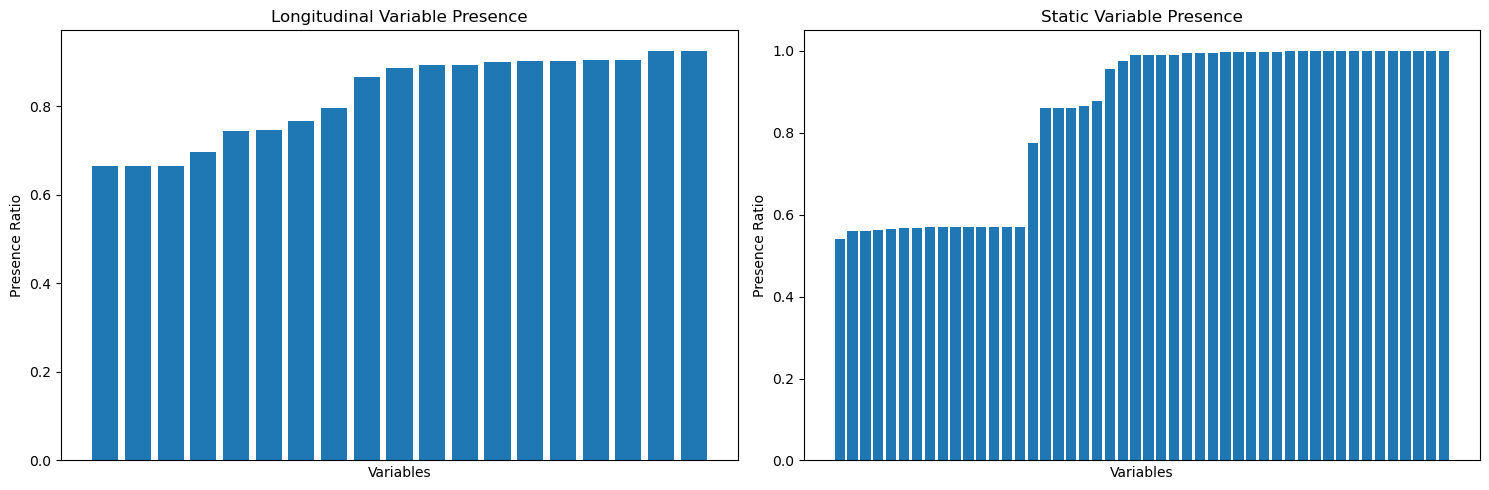

✅ Data processing completed successfully!


In [40]:
# Visualization
plt.figure(figsize=(15, 5))

# Longitudinal data presence
plt.subplot(1, 2, 1)
long_presence_sorted = long_presence.sort_values()
plt.bar(range(len(long_presence_sorted)), long_presence_sorted.values)
plt.title('Longitudinal Variable Presence')
plt.xlabel('Variables')
plt.ylabel('Presence Ratio')
plt.xticks([])

# Static data presence
plt.subplot(1, 2, 2)
static_presence_sorted = static_presence.sort_values()
plt.bar(range(len(static_presence_sorted)), static_presence_sorted.values)
plt.title('Static Variable Presence')
plt.xlabel('Variables')
plt.ylabel('Presence Ratio')
plt.xticks([])

plt.tight_layout()
plt.show()

print("✅ Data processing completed successfully!")

In [46]:
sns.set(style="whitegrid")

# ---- PARAMETERS ----
N_PATIENTS_SAMPLE = 10
N_PATIENTS_MISSING_HEATMAP = 50

# ---- LONGITUDINAL TRAJECTORIES ----
def plot_longitudinal_trajectories(df_long, vars=['psa']):
    sampled_patients = df_long['PTID'].dropna().unique()[:N_PATIENTS_SAMPLE]
    df_subset = df_long[df_long['PTID'].isin(sampled_patients)]

    for var in vars:
        if var in df_long.columns:
            plt.figure(figsize=(12, 5))
            sns.lineplot(data=df_subset, x='EXAMDATE', y=var, hue='PTID', marker="o", legend=False)
            plt.title(f"{var.upper()} Trajectories for {N_PATIENTS_SAMPLE} Patients")
            plt.xlabel("Date")
            plt.ylabel(var.upper())
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

# ---- STATIC DISTRIBUTIONS ----
def plot_static_distributions(df_static, features=['Current Age', 'Sex', 'Stage (Highest Recorded)']):
    """
    Plot distributions of static features using Matplotlib subplots
    """
    n = len(features)
    plt.figure(figsize=(5 * n, 4))

    for i, feature in enumerate(features, 1):
        plt.subplot(1, n, i)
        if df_static[feature].nunique() < 10:
            counts = df_static[feature].value_counts()
            plt.bar(range(len(counts)), counts.values)
            plt.xticks(range(len(counts)), counts.index.astype(str), rotation=45)
            plt.ylabel('Count')
        else:
            plt.hist(df_static[feature].dropna(), bins=20, edgecolor='black', alpha=0.7)
            plt.ylabel('Frequency')
        plt.title(feature)
        plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

# ---- MISSINGNESS (SIDE-BY-SIDE BAR PLOTS) ----
def plot_presence_side_by_side(df_long, df_static):
    """
    Bar plots of variable presence for longitudinal and static data
    """
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PTID', 'EXAMDATE']]
    long_presence = (~df_long[long_vars_to_analyze].isna()).mean().sort_values()
    static_presence = (~df_static.isna()).mean().sort_values()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.bar(range(len(long_presence)), long_presence.values)
    plt.title('Longitudinal Variable Presence')
    plt.xlabel('Variables')
    plt.ylabel('Presence Ratio')
    plt.xticks([])

    plt.subplot(1, 2, 2)
    plt.bar(range(len(static_presence)), static_presence.values)
    plt.title('Static Variable Presence')
    plt.xlabel('Variables')
    plt.ylabel('Presence Ratio')
    plt.xticks([])

    plt.tight_layout()
    plt.show()

    print("✅ Presence visualization completed successfully!")

def plot_missing_data_heatmap(df_long, df_static, max_vars=20):
    """
    Create heatmaps showing missing data patterns
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # Longitudinal missing data heatmap
    long_missing = df_long.isna()
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PTID', 'EXAMDATE']]
    long_missing = long_missing[long_vars_to_analyze]
    long_missing_pct = long_missing.sum() / len(long_missing) * 100
    
    # Select top variables with most missing data
    top_long_vars = long_missing_pct.nlargest(max_vars).index
    long_subset = long_missing[top_long_vars]
    
    # Create patient-level missing pattern (sample of patients)
    sample_patients = df_long['PTID'].unique()[:N_PATIENTS_MISSING_HEATMAP]
    long_patient_missing = long_subset[df_long['PTID'].isin(sample_patients)]
    
    sns.heatmap(long_patient_missing.T, 
                cbar_kws={'label': 'Missing'}, 
                ax=axes[0], 
                cmap='Reds',
                yticklabels=True,
                xticklabels=False)
    axes[0].set_title('Longitudinal Data Missing Patterns (Sample Patients)')
    axes[0].set_ylabel('Variables')
    
    # Static missing data heatmap
    static_missing = df_static.isna()
    static_missing_pct = static_missing.sum() / len(static_missing) * 100
    
    # Select variables with missing data
    vars_with_missing = static_missing_pct[static_missing_pct > 0].index
    if len(vars_with_missing) > 0:
        static_subset = static_missing[vars_with_missing]
        sns.heatmap(static_subset.T, 
                    cbar_kws={'label': 'Missing'}, 
                    ax=axes[1], 
                    cmap='Reds',
                    yticklabels=True,
                    xticklabels=False)
        axes[1].set_title('Static Data Missing Patterns')
        axes[1].set_ylabel('Variables')
    
    plt.tight_layout()
    plt.show()

# ---- VISIT PATTERNS ----
def plot_patient_visit_summary(df_long):
    visits = df_long.groupby('PTID')['EXAMDATE'].count()
    plt.figure(figsize=(8, 4))
    plt.hist(visits, bins=20, edgecolor='black', alpha=0.7)
    plt.title("Distribution of Visits per Patient")
    plt.xlabel("Number of Visits")
    plt.ylabel("Patients")
    plt.tight_layout()
    plt.show()
    print(f"Avg visits: {visits.mean():.1f}, Max: {visits.max()}, Min: {visits.min()}")

# ---- CORRELATION ANALYSIS ----
def plot_correlation(df_static, df_long):
    """
    Plot correlation heatmap between static and longitudinal variables
    """
    # Get numeric static variables
    df_static_num = df_static.select_dtypes(include=np.number)
    
    # Get numeric longitudinal variables and compute patient means
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PTID', 'EXAMDATE']]
    df_long_num = df_long[long_vars_to_analyze].select_dtypes(include=np.number)
    
    if not df_long_num.empty:
        df_long_mean = df_long.groupby('PTID')[df_long_num.columns].mean()
        
        # Combine static and longitudinal data
        df_combined = pd.merge(df_static_num, df_long_mean, 
                              left_index=True, right_index=True, how='inner')
        
        # Compute correlation
        corr = df_combined.corr()
        
        # Create mask for upper triangle
        mask = np.triu(np.ones_like(corr, dtype=bool))
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, 
                   annot=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title("Correlation Heatmap: Static vs Longitudinal Variables")
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric longitudinal variables found for correlation analysis")

# ---- DATA QUALITY DASHBOARD ----
def create_data_quality_dashboard(df_long, df_static):
    """
    Create a comprehensive data quality dashboard
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Longitudinal data presence
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PTID', 'EXAMDATE']]
    long_presence = (~df_long[long_vars_to_analyze].isna()).mean().sort_values()
    axes[0, 0].bar(range(len(long_presence)), long_presence.values)
    axes[0, 0].set_title('Longitudinal Variable Presence')
    axes[0, 0].set_ylabel('Presence Ratio')
    
    # 2. Static data presence
    static_presence = (~df_static.isna()).mean().sort_values()
    axes[0, 1].bar(range(len(static_presence)), static_presence.values)
    axes[0, 1].set_title('Static Variable Presence')
    axes[0, 1].set_ylabel('Presence Ratio')
    
    # 3. Visit distribution
    visits = df_long.groupby('PTID')['EXAMDATE'].count()
    axes[0, 2].hist(visits, bins=20, edgecolor='black', alpha=0.7)
    axes[0, 2].set_title('Visits per Patient')
    axes[0, 2].set_xlabel('Number of Visits')
    axes[0, 2].set_ylabel('Patients')
    
    # 4. Time span distribution
    time_spans = df_long.groupby('PTID')['EXAMDATE'].agg(['min', 'max'])
    time_spans['span'] = time_spans['max'] # - time_spans['min']
    axes[1, 0].hist(time_spans['span'], bins=20, edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Patient Time Span')
    axes[1, 0].set_xlabel('Days')
    axes[1, 0].set_ylabel('Patients')
    
    # 5. Age distribution (if available)
    if 'AGE' in df_static.columns:
        axes[1, 1].hist(df_static['AGE'].dropna(), bins=20, edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('Age Distribution')
        axes[1, 1].set_xlabel('Age')
        axes[1, 1].set_ylabel('Patients')
    else:
        axes[1, 1].text(0.5, 0.5, 'Age data not available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Age Distribution')
    
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=== DATA QUALITY SUMMARY ===")
    print(f"Total patients: {df_static.shape[0]}")
    print(f"Longitudinal records: {len(df_long)}")
    print(f"Longitudinal variables: {len(long_vars_to_analyze)}")
    print(f"Static variables: {df_static.shape[1]}")
    print(f"Average visits per patient: {visits.mean():.1f}")
    print(time_spans['span'])
    print(f"Time span range: {time_spans['span'].min():.0f} to {time_spans['span'].max():.0f} days")

# ---- WRAPPER ----
def analyze(df_long, df_static):
    """
    Comprehensive analysis of ADNI data
    """
    print("📈 Longitudinal trajectories...")
    plot_longitudinal_trajectories(df_long, vars=['CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE',
       'RAVLT_immediate', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'TRABSCOR',
       'FAQ', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal',
       'Fusiform', 'MidTemp', 'ICV', 'mPACCdigit', 'mPACCtrailsB'])

    print("📊 Static feature distributions...")
    plot_static_distributions(df_static, features=['DX_bl', 'AGE', 'PTGENDER'])

    print("�� Presence bar plots...")
    plot_presence_side_by_side(df_long, df_static)
    
    print("🔥 Missing data heatmaps...")
    plot_missing_data_heatmap(df_long, df_static, max_vars=20)

    print("📅 Visit patterns...")
    plot_patient_visit_summary(df_long)
    
    print("🔗 Correlation analysis...")
    plot_correlation(df_static, df_long)
    
    print("📊 Data quality dashboard...")
    create_data_quality_dashboard(df_long, df_static)
    
    print("✅ ADNI data analysis completed!")

In [47]:
df_long_final.columns

Index(['PTID', 'EXAMDATE', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE',
       'RAVLT_immediate', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'TRABSCOR',
       'FAQ', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal',
       'Fusiform', 'MidTemp', 'ICV', 'mPACCdigit', 'mPACCtrailsB'],
      dtype='object')

📈 Longitudinal trajectories...


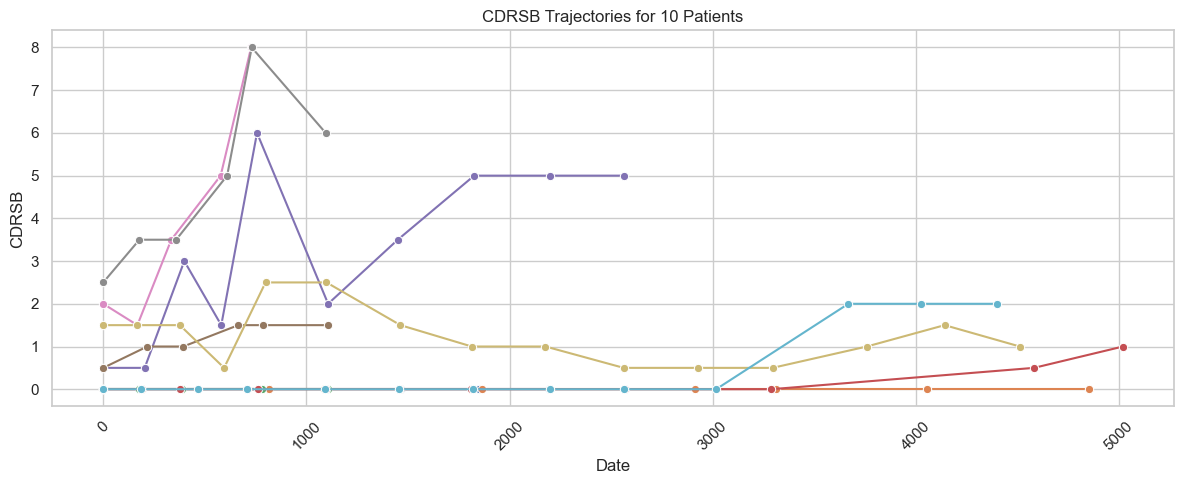

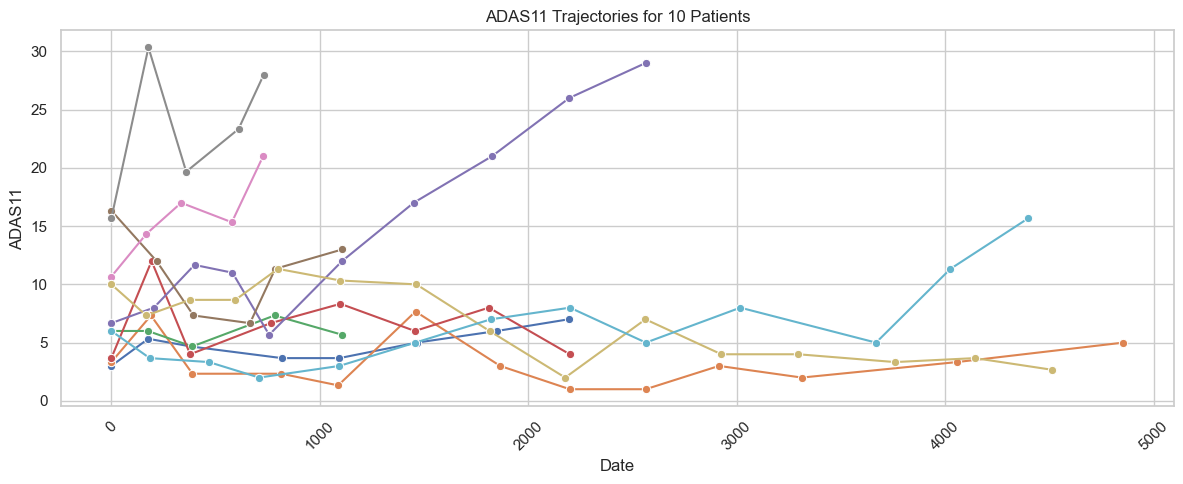

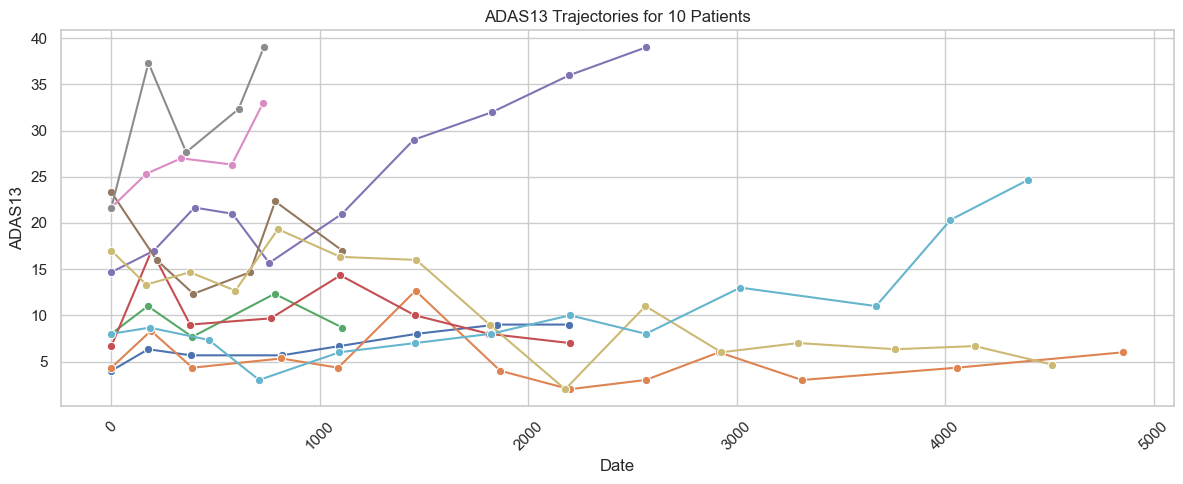

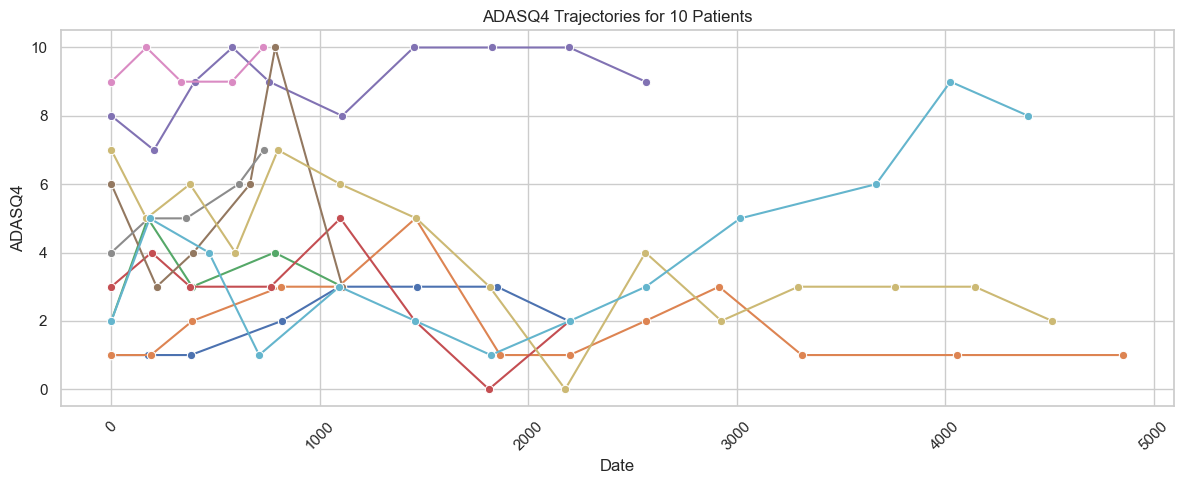

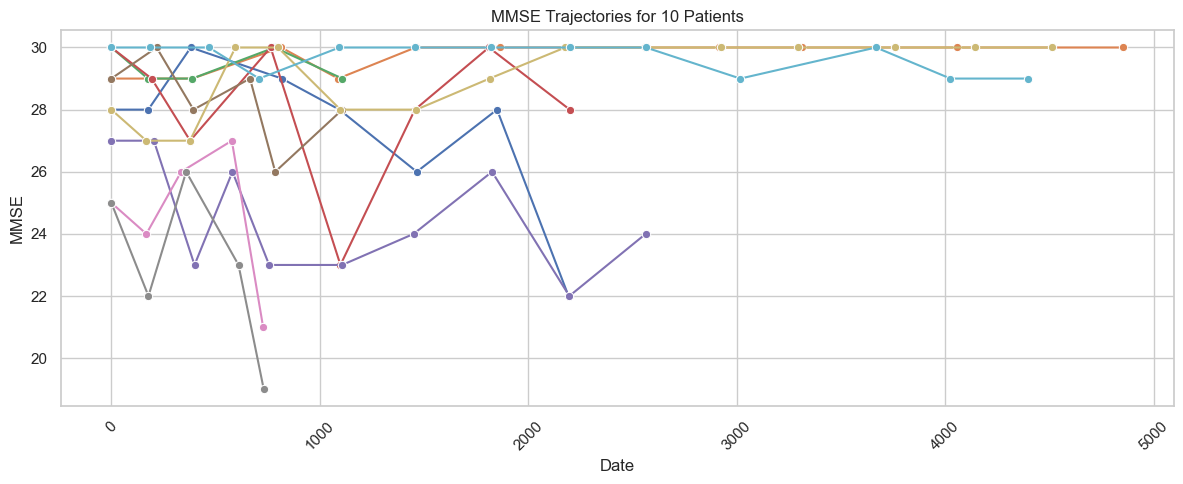

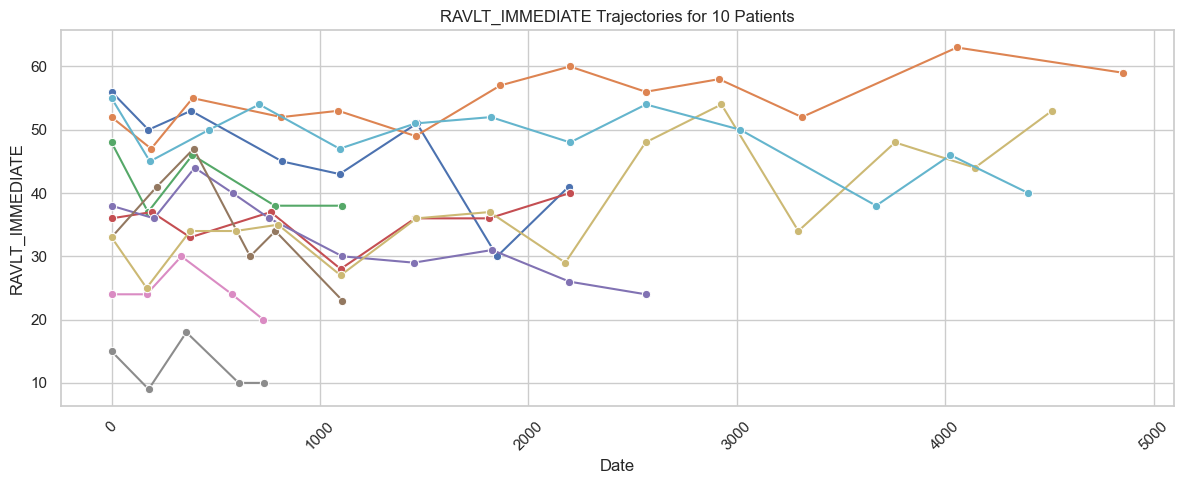

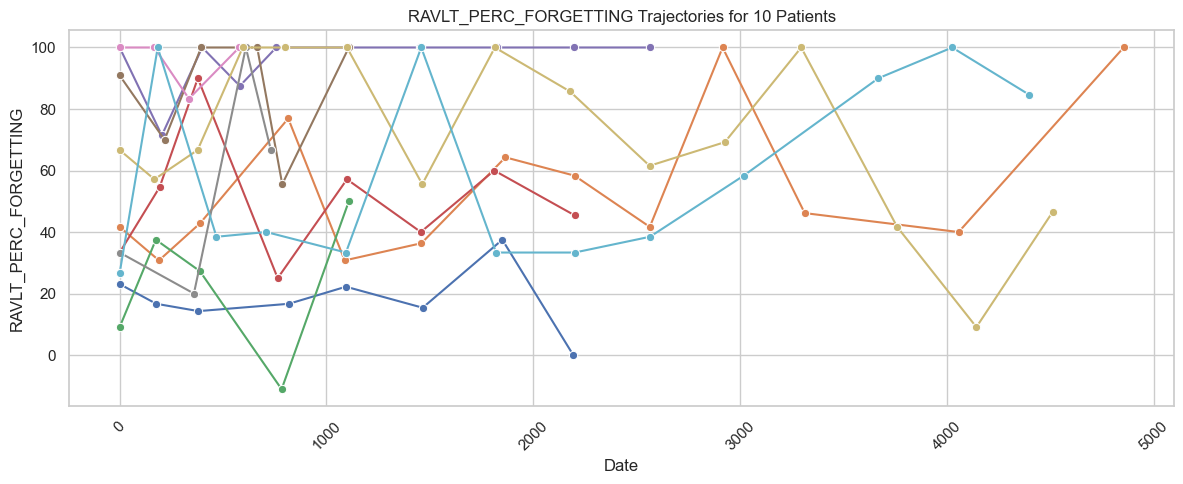

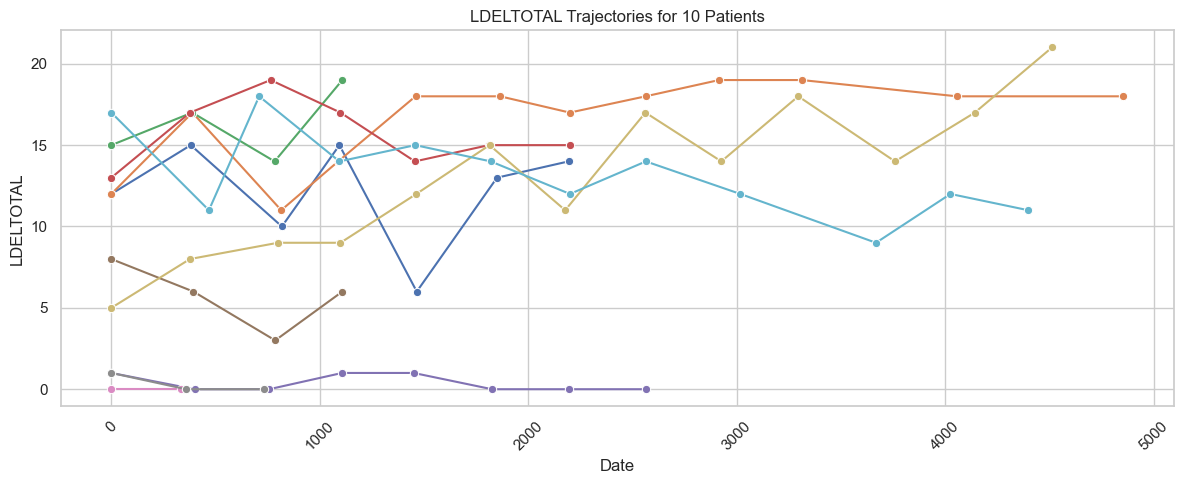

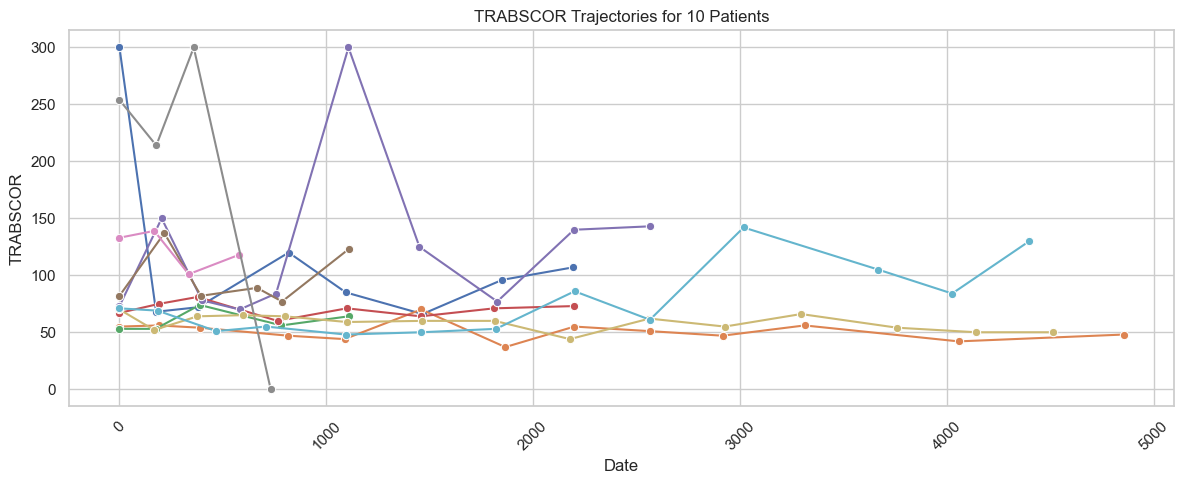

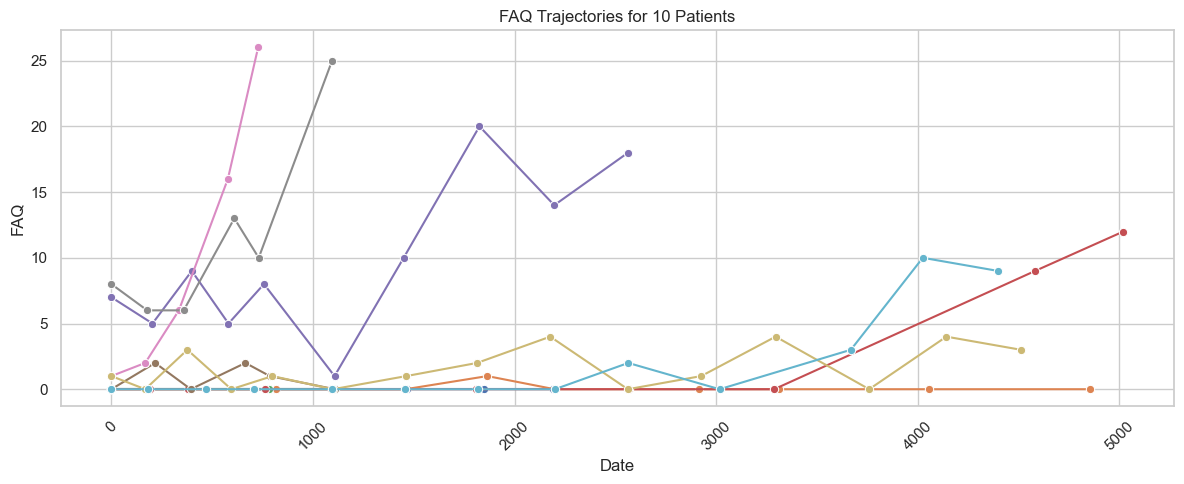

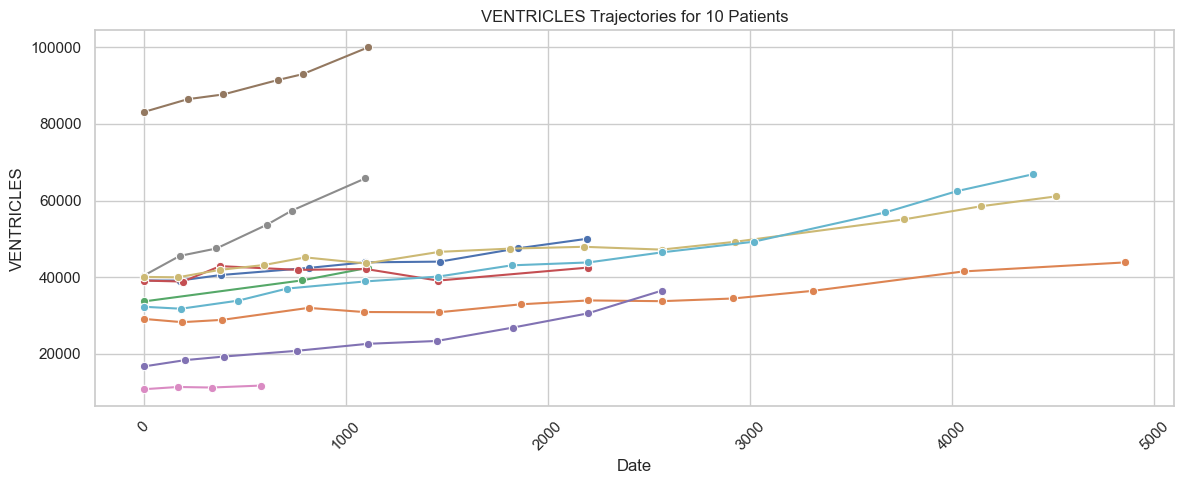

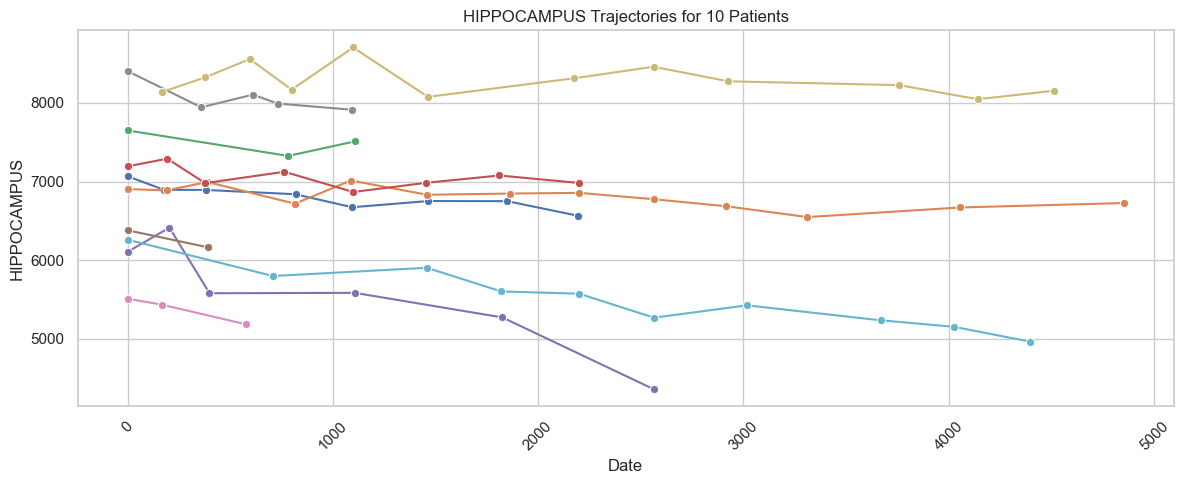

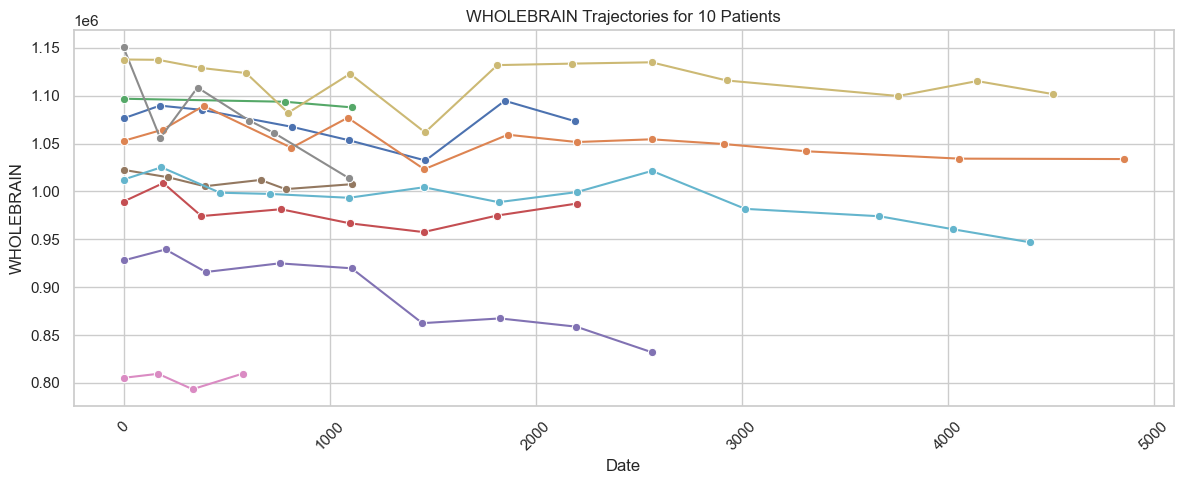

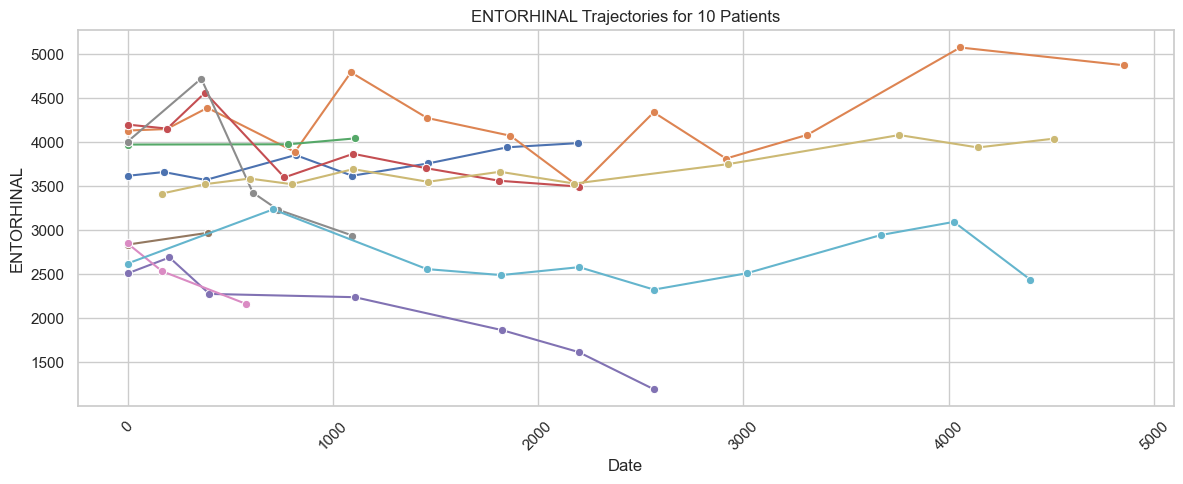

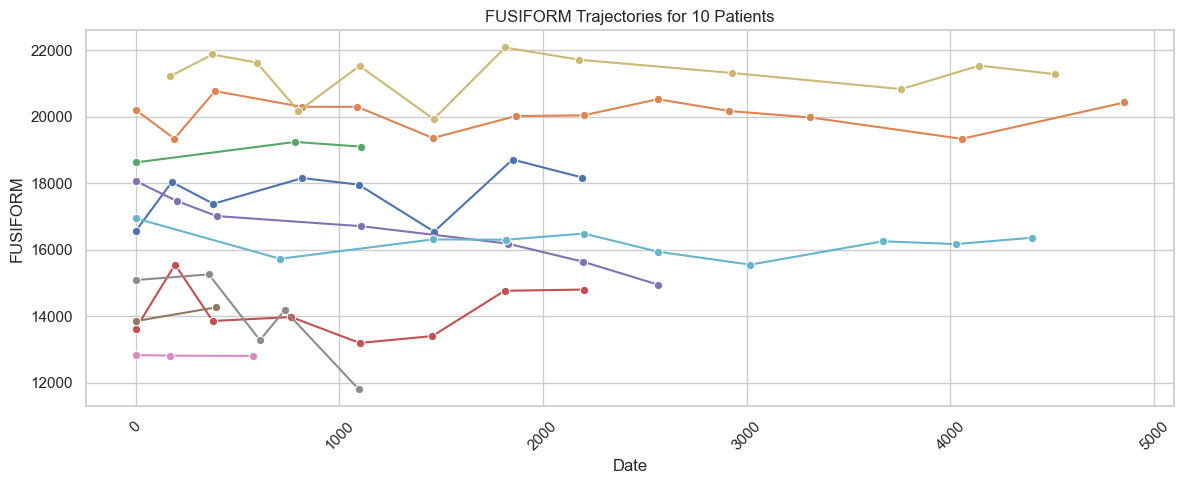

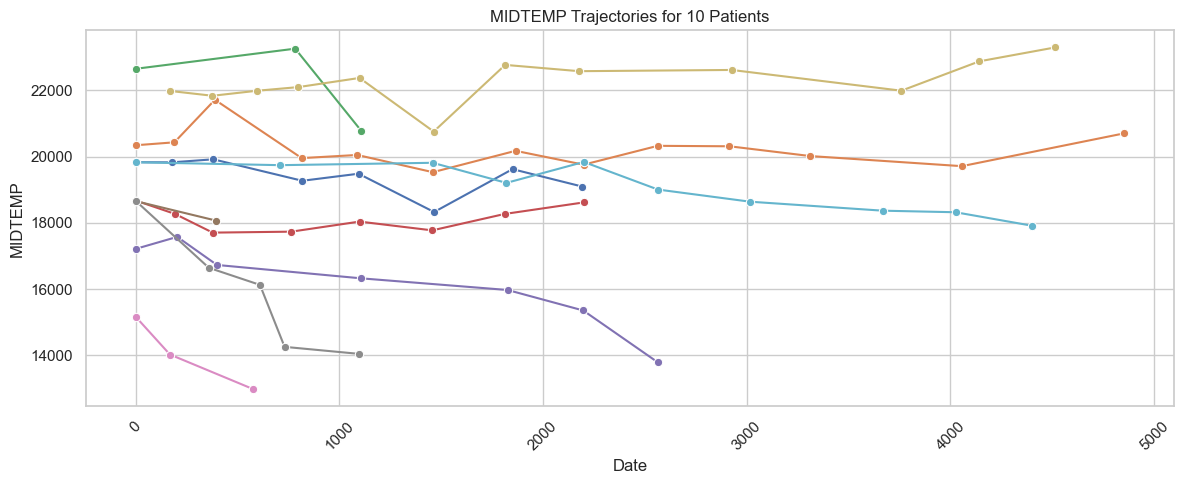

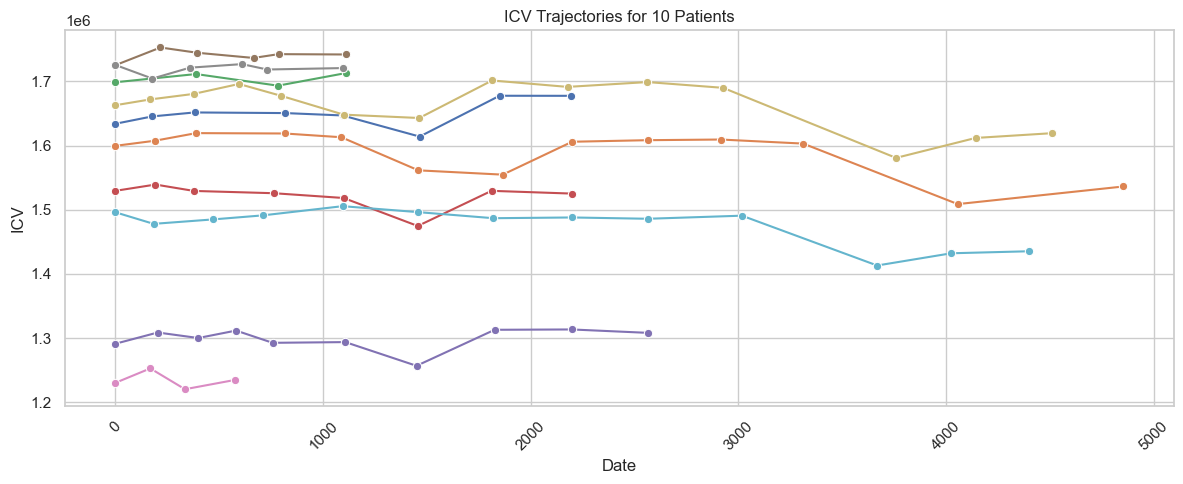

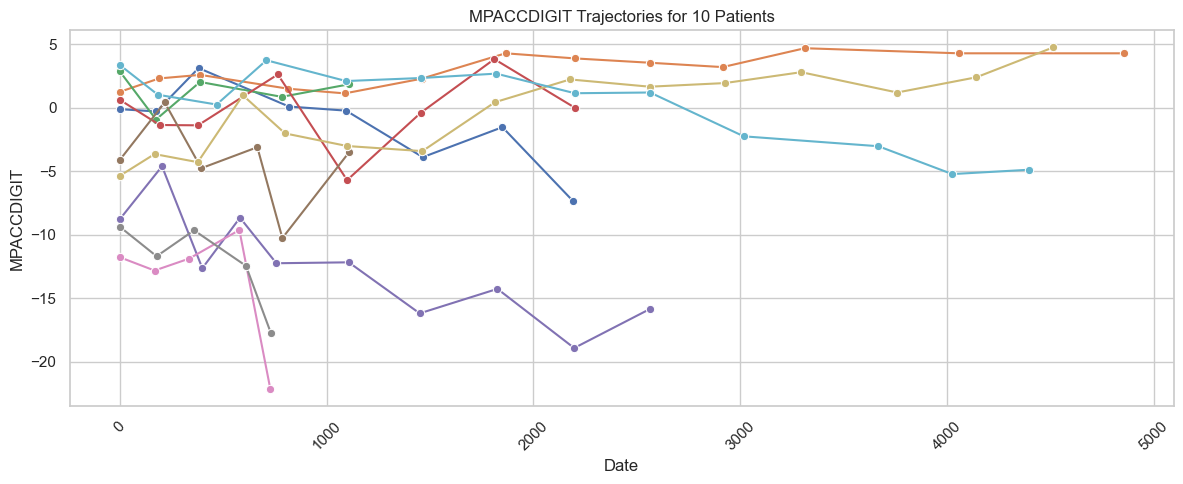

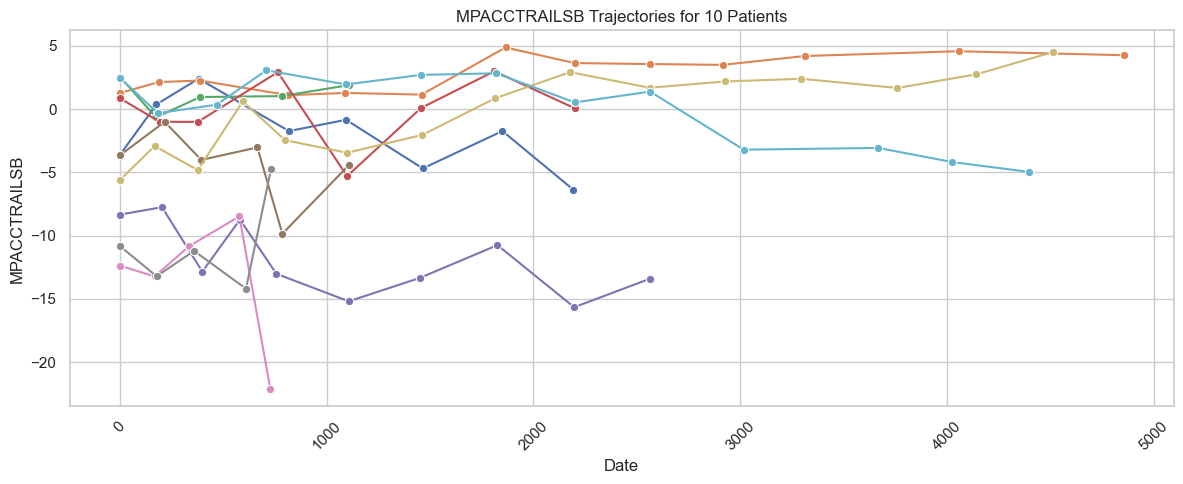

📊 Static feature distributions...


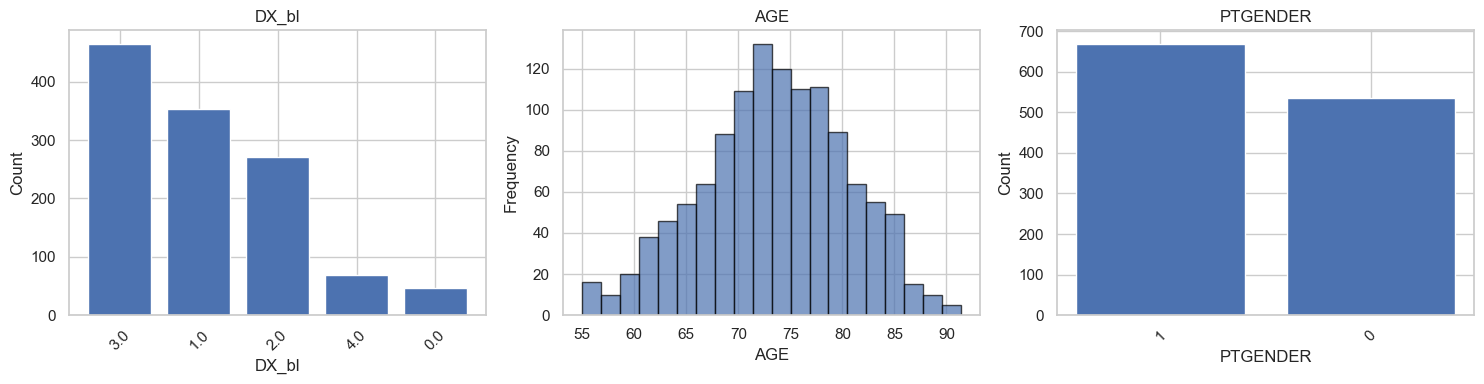

�� Presence bar plots...


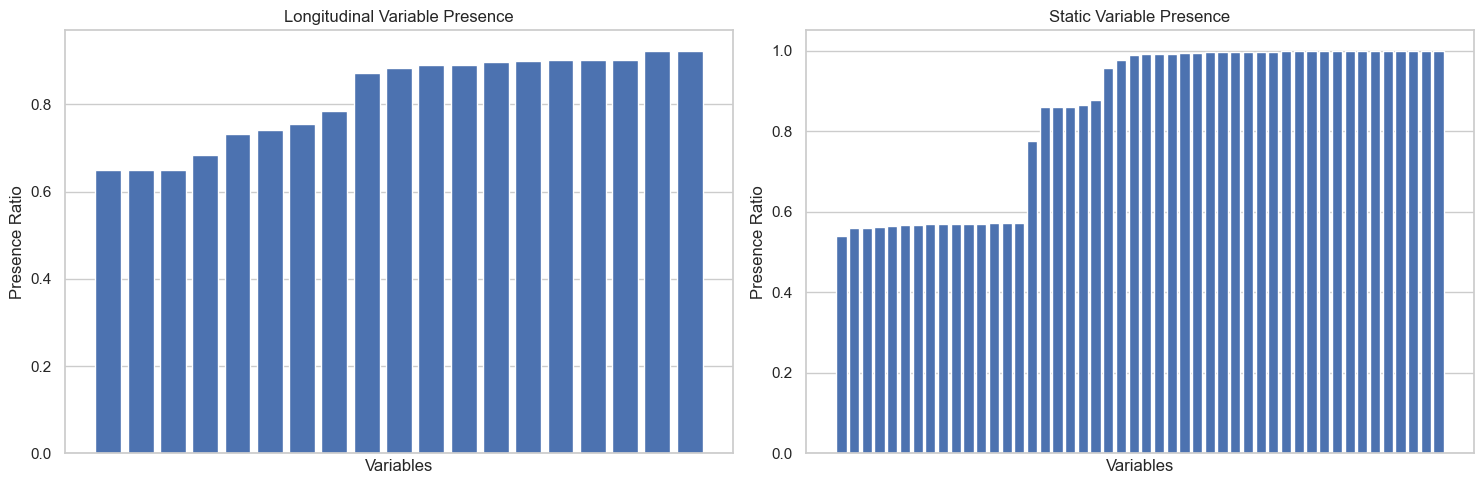

✅ Presence visualization completed successfully!
🔥 Missing data heatmaps...


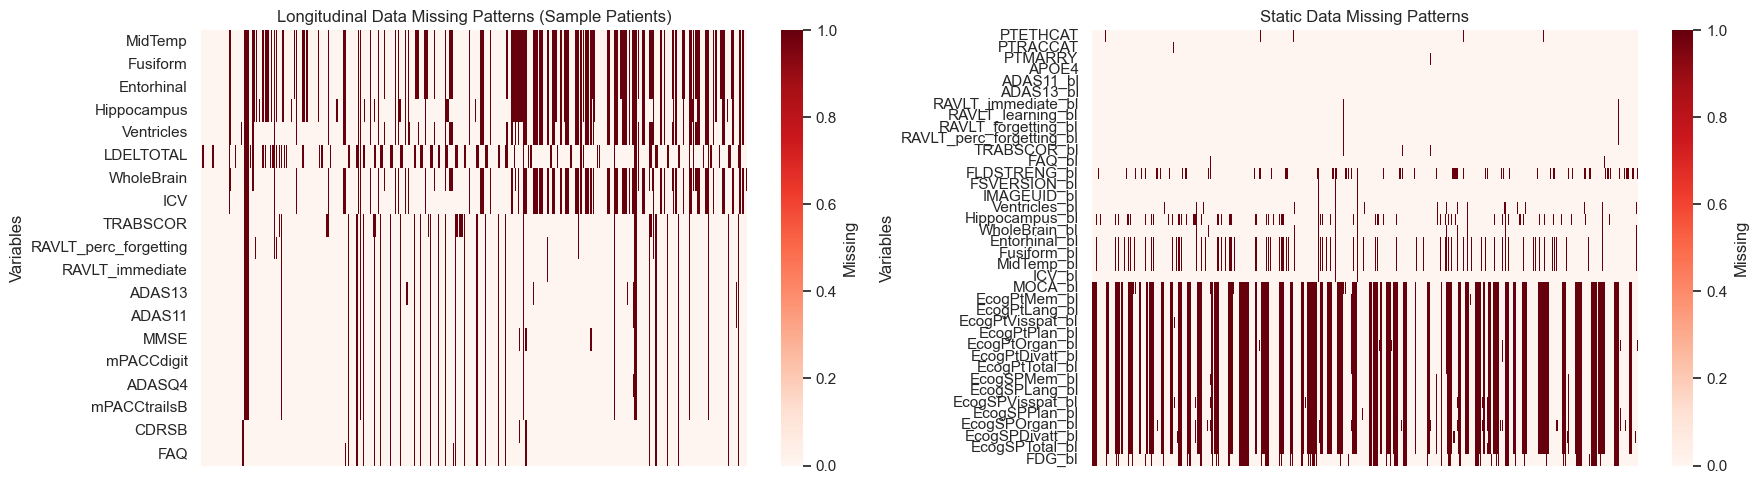

📅 Visit patterns...


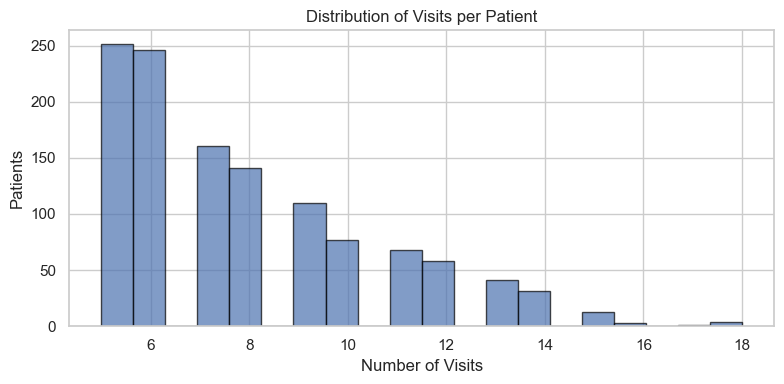

Avg visits: 7.9, Max: 18, Min: 5
🔗 Correlation analysis...


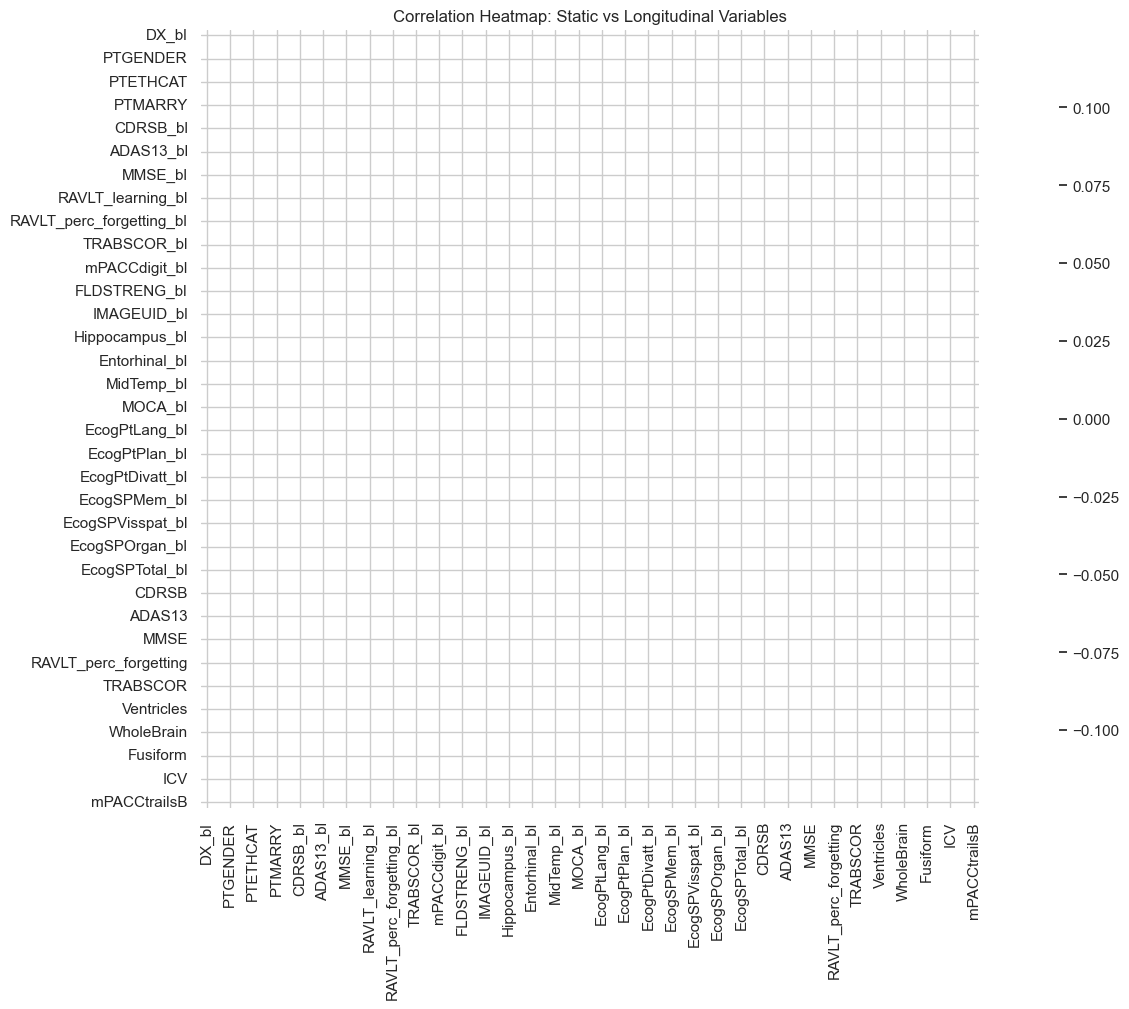

📊 Data quality dashboard...


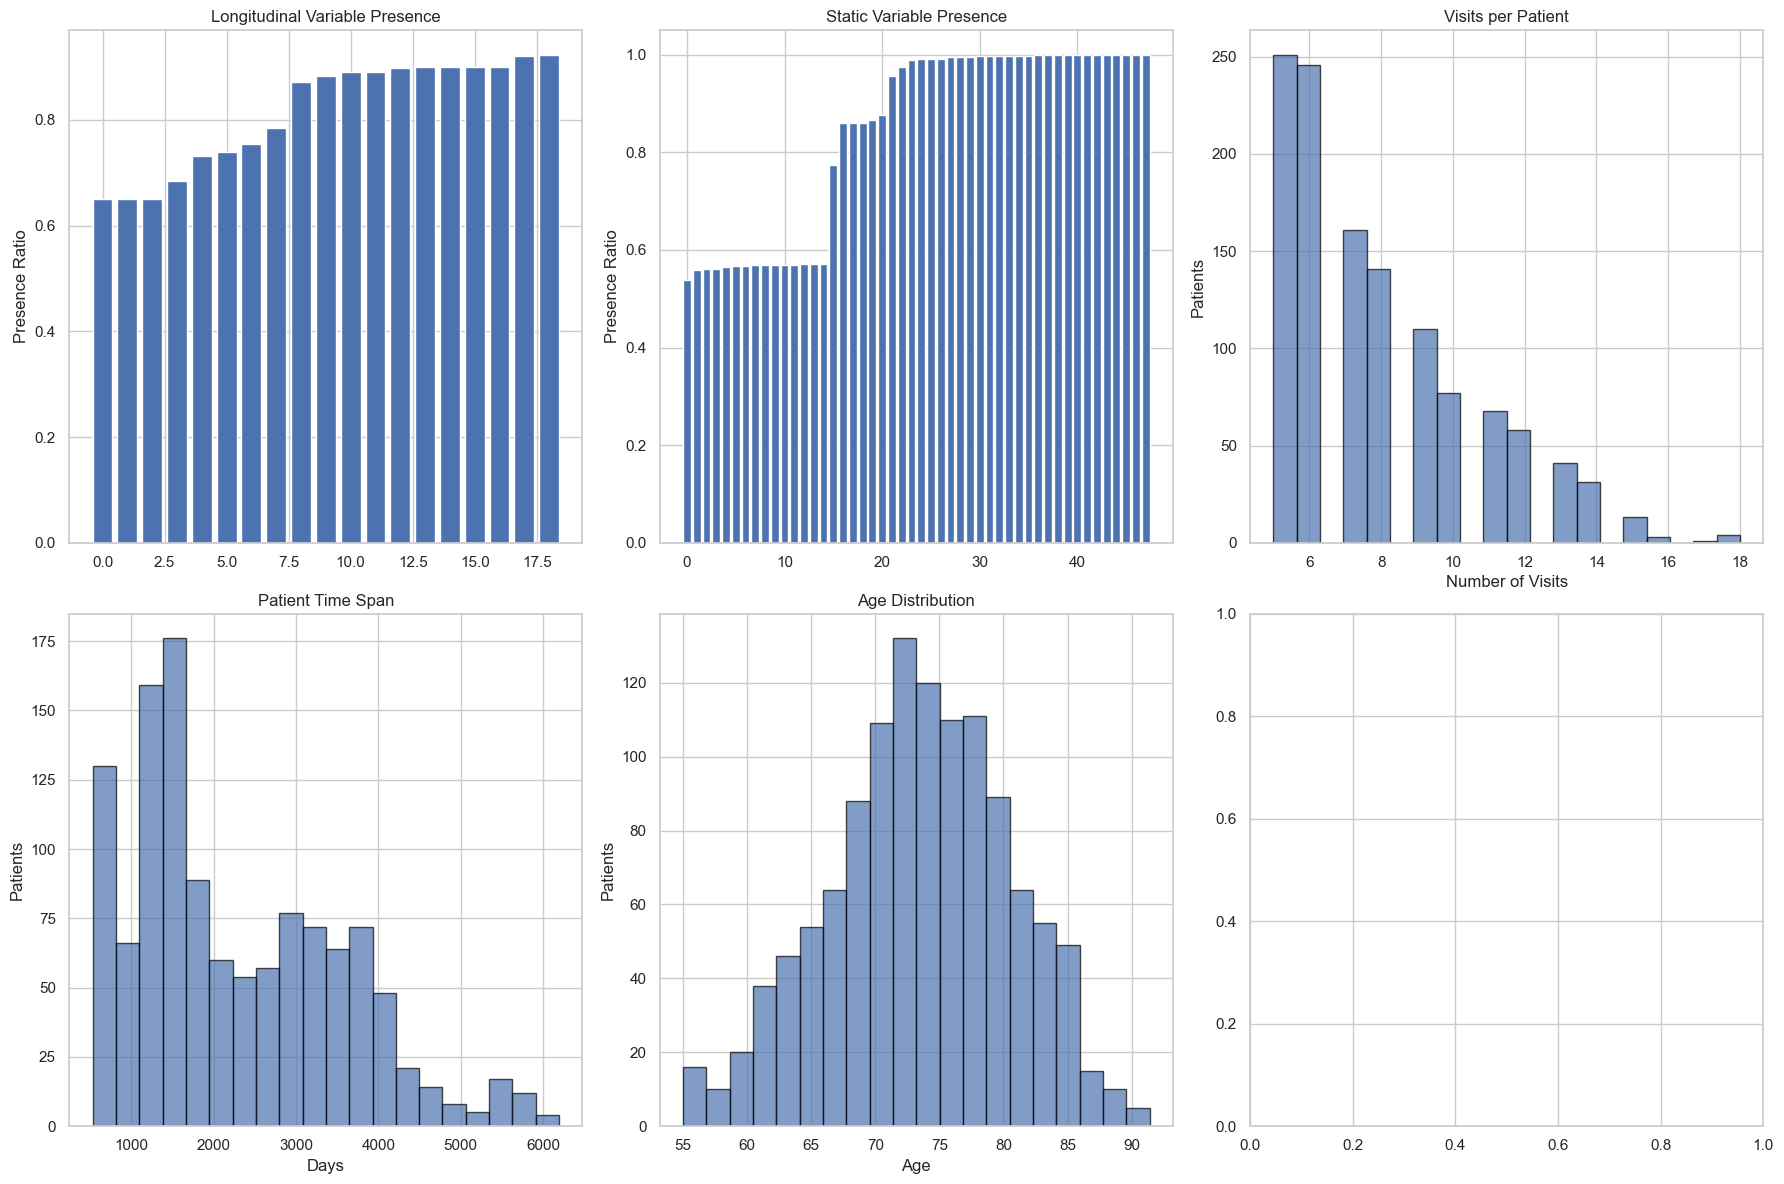

=== DATA QUALITY SUMMARY ===
Total patients: 1205
Longitudinal records: 9489
Longitudinal variables: 19
Static variables: 48
Average visits per patient: 7.9
PTID
002_S_0295    2193.0
002_S_0413    4854.0
002_S_0559    1108.0
002_S_0685    5020.0
002_S_0729    2563.0
               ...  
941_S_4420    2044.0
941_S_4764    1102.0
941_S_5124    3276.0
941_S_5193    2199.0
941_S_6068    1812.0
Name: span, Length: 1205, dtype: float64
Time span range: 529 to 6195 days
✅ ADNI data analysis completed!


In [48]:
analyze(df_long_final, df_static_final)